# Scope, inputs, and estimands

This notebook starts from the dated PIF and YPLL result artifacts generated upstream. It additionally reads the dated alcohol-attributable mortality workbook and the official projected-population workbook stored in the control directory. These two supplementary inputs support the requested sex-specific rates and descriptive alcohol-attributable mortality table; the PIF estimands themselves are not recomputed.

No ENPG microdata, relative-risk function, external R script, or previously created in-memory object is required. The latest matching dated result is selected from its filename, and every selected path is reported before any figure or table is calculated.

The main estimands are:

1. **Potential Impact Fraction (PIF):** the proportional change in cause-specific population risk under a counterfactual exposure distribution relative to the observed distribution.
2. **Avoidable deaths:** observed deaths multiplied by the corresponding PIF.
3. **Avoidable YLL:** observed years of life lost multiplied by the corresponding PIF. This uses total cause-specific YLL, not alcohol-attributable YLL multiplied by PIF.
4. **Burden-weighted PIF:** the sum of avoidable burden divided by the sum of the corresponding observed burden across the cells being summarized.

Negative PIF values are retained because J-shaped relative-risk functions can imply increased risk after a volume reduction in some cells. Non-applicable HED scenarios remain missing and are never recoded as zero.

The lower and upper values available in the result files are cell-level Monte Carlo limits. When cells are aggregated, this notebook sums the cell-level lower and upper burdens to provide an uncertainty envelope. That envelope is useful descriptively, but it is not a newly simulated joint 95% uncertainty interval for the aggregate.


In [1]:
#| label: pif3-setup
#| results: "hold"
.t0 <- Sys.time()
# Keep the notebook safe in an interactive Positron session while ensuring that every analytical object created below has a pif3_ prefix.
pif3_clear_workspace <- FALSE
if (isTRUE(pif3_clear_workspace)) {
  base::rm(list = base::ls())
  invisible(base::gc())
}
# Export both a high-resolution TIFF and a vector PDF for each completed figure.
pif3_export_figures <- TRUE
# Print provenance, validation results, join coverage, and export locations.
pif3_verbose <- TRUE
# Use only packages needed for data manipulation, plotting, rendering, and the session-information appendix.
pif3_required_packages <- c("dplyr", "tidyr", "tibble", "ggplot2", "scales", "forcats", "knitr", "htmltools", "withr", "readxl", "readxl")
pif3_missing_packages <- pif3_required_packages[!base::vapply(pif3_required_packages, base::requireNamespace, logical(1), quietly = TRUE)]
if (base::length(pif3_missing_packages) > 0L) {
  base::stop("Missing required package(s): ", base::paste(pif3_missing_packages, collapse = ", "))
}
base::message(base::sprintf("pif3-setup elapsed minutes: %.2f", base::as.numeric(base::difftime(Sys.time(), .t0, units = "mins"))))


pif3-setup elapsed minutes: 0.02



## Reproducible artifact discovery

The selector below accepts execution from either the project root or the control directory. It requires exact dated filename stems, prefers the embedded YYYYMMDD value, and uses modification time only to resolve ties. The undated legacy YPLL file is intentionally excluded. The population workbook is a stable project input rather than a dated result.


In [2]:
#| label: pif3-artifact-helpers
#| results: "hold"
.t0 <- Sys.time()
pif3_elapsed_min <- function(.start = .t0) {
  base::as.numeric(base::difftime(Sys.time(), .start, units = "mins"))
}
pif3_message <- function(..., verbose = pif3_verbose) {
  if (isTRUE(verbose)) {
    base::message(base::sprintf(...))
  }
}
pif3_find_project_dirs <- function(verbose = pif3_verbose) {
  # Positron and Quarto can execute the notebook from different working directories, so test the current directory and its parent explicitly.
  raw_candidates <- base::unique(c(base::getwd(), base::dirname(base::getwd()), base::normalizePath(base::file.path(base::getwd(), ".."), winslash = "/", mustWork = FALSE)))
  candidates <- base::unique(base::normalizePath(raw_candidates, winslash = "/", mustWork = FALSE))
  hits <- candidates[base::dir.exists(base::file.path(candidates, "__andres_control")) & base::dir.exists(base::file.path(candidates, "Mortalidad", "Matrices"))]
  if (!base::length(hits)) {
    base::stop("Could not identify the project root containing __andres_control and Mortalidad/Matrices from getwd(): ", base::getwd())
  }
  root_dir <- base::normalizePath(hits[[1L]], winslash = "/", mustWork = TRUE)
  control_dir <- base::normalizePath(base::file.path(root_dir, "__andres_control"), winslash = "/", mustWork = TRUE)
  ypll_dir <- base::normalizePath(base::file.path(root_dir, "Mortalidad", "Matrices"), winslash = "/", mustWork = TRUE)
  pif3_message("[directories] Project root: %s", root_dir, verbose = verbose)
  pif3_message("[directories] Control directory: %s", control_dir, verbose = verbose)
  pif3_message("[directories] YPLL directory: %s", ypll_dir, verbose = verbose)
  list(root = root_dir, control = control_dir, ypll = ypll_dir)
}
pif3_latest_dated_file <- function(directory, stem, extension = "rds", verbose = pif3_verbose) {
  # Match only stem_YYYYMMDD.extension so similarly named audit, Table 5, smoke-test, and undated legacy files cannot be selected accidentally.
  directory <- base::normalizePath(directory, winslash = "/", mustWork = TRUE)
  pattern <- base::paste0("^", stem, "_([0-9]{8})\\.", extension, "$")
  paths <- base::list.files(directory, pattern = pattern, full.names = TRUE)
  if (!base::length(paths)) {
    base::stop("No dated artifact matched ", pattern, " under ", directory)
  }
  file_names <- base::basename(paths)
  date_text <- base::sub(pattern, "\\1", file_names)
  embedded_date <- base::as.Date(date_text, format = "%Y%m%d")
  file_info <- base::file.info(paths)
  candidates <- tibble::tibble(path = base::normalizePath(paths, winslash = "/", mustWork = TRUE), file_name = file_names, embedded_date = embedded_date, modified_time = file_info$mtime, size_bytes = file_info$size) |>
    dplyr::arrange(dplyr::desc(.data$embedded_date), dplyr::desc(.data$modified_time), dplyr::desc(.data$size_bytes))
  pif3_message("[latest-file] Pattern: %s", pattern, verbose = verbose)
  pif3_message("[latest-file] Candidate count: %d", base::nrow(candidates), verbose = verbose)
  pif3_message("[latest-file] Selected by embedded date: %s", candidates$file_name[[1L]], verbose = verbose)
  selected <- candidates$path[[1L]]
  base::attr(selected, "candidates") <- candidates
  selected
}
pif3_read_rds <- function(path, verbose = pif3_verbose) {
  pif3_message("[read-rds] Reading: %s", path, verbose = verbose)
  object <- base::readRDS(path)
  base::attr(object, "path") <- path
  object
}
pif3_dirs <- pif3_find_project_dirs()
base::message(base::sprintf("pif3-artifact-helpers elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[directories] Project root: C:/Users/nDP/Desktop/ACC1240138_private



[directories] Control directory: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control



[directories] YPLL directory: C:/Users/nDP/Desktop/ACC1240138_private/Mortalidad/Matrices



pif3-artifact-helpers elapsed minutes: 0.00



In [3]:
#| label: pif3-load-artifacts
#| results: "hold"
.t0 <- Sys.time()
# Select the latest complete PIF grid, independently tested injuries grid, dated YPLL artifact, and alcohol-attributable mortality workbook.
pif3_pif_path <- pif3_latest_dated_file(pif3_dirs$control, "pif2_pif_results_full")
pif3_injuries_path <- pif3_latest_dated_file(pif3_dirs$control, "pif2_injuries_fulltest_results")
pif3_ypll_path <- pif3_latest_dated_file(pif3_dirs$ypll, "YPLL")
pif3_mortality_path <- pif3_latest_dated_file(pif3_dirs$control, "Mortality Estimates WHO 2024", extension = "xlsx")
pif3_population_path <- base::file.path(pif3_dirs$control, "ine_proyecciones_2012_2024.xlsx")
if (!base::file.exists(pif3_population_path)) base::stop("Population workbook not found: ", pif3_population_path)
pif3_pif_results <- pif3_read_rds(pif3_pif_path)
pif3_injuries_results <- pif3_read_rds(pif3_injuries_path)
pif3_ypll <- pif3_read_rds(pif3_ypll_path)
pif3_mortality_raw <- readxl::read_xlsx(pif3_mortality_path)
pif3_population_raw <- list(Hombres = readxl::read_xlsx(pif3_population_path, sheet = "Hombres"), Mujeres = readxl::read_xlsx(pif3_population_path, sheet = "Mujeres"))
pif3_provenance <- tibble::tibble(artifact = c("Full PIF grid", "Full injuries test grid", "Mortality and YLL", "Alcohol-attributable mortality", "Projected population"), file = base::basename(c(pif3_pif_path, pif3_injuries_path, pif3_ypll_path, pif3_mortality_path, pif3_population_path)), path = c(pif3_pif_path, pif3_injuries_path, pif3_ypll_path, pif3_mortality_path, pif3_population_path), rows = c(base::nrow(pif3_pif_results), base::nrow(pif3_injuries_results), base::nrow(pif3_ypll), base::nrow(pif3_mortality_raw), base::sum(base::vapply(pif3_population_raw, base::nrow, integer(1)))), columns = c(base::ncol(pif3_pif_results), base::ncol(pif3_injuries_results), base::ncol(pif3_ypll), base::ncol(pif3_mortality_raw), base::max(base::vapply(pif3_population_raw, base::ncol, integer(1)))))
base::print(knitr::kable(pif3_provenance, format = "simple", caption = "Input artifact provenance"))
base::message(base::sprintf("pif3-load-artifacts elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[latest-file] Pattern: ^pif2_pif_results_full_([0-9]{8})\.rds$



[latest-file] Candidate count: 5



[latest-file] Selected by embedded date: pif2_pif_results_full_20260720.rds



[latest-file] Pattern: ^pif2_injuries_fulltest_results_([0-9]{8})\.rds$



[latest-file] Candidate count: 4



...

[read-rds] Reading: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/pif2_pif_results_full_20260720.rds



[read-rds] Reading: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/pif2_injuries_fulltest_results_20260721.rds



[read-rds] Reading: C:/Users/nDP/Desktop/ACC1240138_private/Mortalidad/Matrices/YPLL_20260714.rds





Table: Input artifact provenance

artifact                         file                                          path                                                                                                     rows   columns
-------------------------------  --------------------------------------------  -----------------------------------------------------------------------------------------------------  ------  --------
Full PIF grid                    pif2_pif_results_full_20260720.rds            C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/pif2_pif_results_full_20260720.rds             20160        24
Full injuries test grid          pif2_injuries_fulltest_results_20260721.rds   C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/pif2_injuries_fulltest_results_20260721.rds     2688        24
Mortality and YLL                YPLL_20260714.rds                             C:/Users/nDP/Desktop/ACC1240138_private/Mortalidad/Matrices/YPLL_20260714.rds            

pif3-load-artifacts elapsed minutes: 0.00



## Structural and numerical validation

The checks below establish that the three files can be combined without silently changing disease definitions, sex strata, years, age groups, scenario applicability, or uncertainty fields. The injuries-only file is cross-checked against the corresponding rows of the complete PIF grid.


In [4]:
#| label: pif3-validate-artifacts
#| results: "hold"
.t0 <- Sys.time()
pif3_required_columns <- function(data, required, object_name) {
  missing <- base::setdiff(required, base::names(data))
  if (base::length(missing)) {
    base::stop(object_name, " is missing required column(s): ", base::paste(missing, collapse = ", "))
  }
  invisible(TRUE)
}
pif3_required_columns(pif3_pif_results, c("disease", "sex", "age_group", "year", "output_name", "scenario_id", "scenario_label", "engine_scenario", "avg_consumption_change_pct", "hed_prevalence_change_pct", "pif", "pif_low", "pif_up", "applicable", "reason", "n_sim"), "Full PIF grid")
pif3_required_columns(pif3_injuries_results, c("disease", "sex", "age_group", "year", "output_name", "scenario_id", "scenario_label", "engine_scenario", "avg_consumption_change_pct", "hed_prevalence_change_pct", "pif", "pif_low", "pif_up", "applicable", "n_sim"), "Full injuries test grid")
pif3_required_columns(pif3_ypll, c("year", "gender", "age_group", "disease", "deaths", "ypll", "yll_hmd", "yll_gbd", "ypll_ref"), "YPLL artifact")
pif3_validation_rows <- list()
pif3_check <- function(check, condition, note) {
  pif3_validation_rows[[base::length(pif3_validation_rows) + 1L]] <<- tibble::tibble(check = check, pass = isTRUE(condition), note = note)
  invisible(NULL)
}
pif3_full_key <- c("disease", "sex", "age_group", "year", "output_name", "scenario_id")
pif3_injury_key <- c("disease", "sex", "age_group", "year", "output_name", "scenario_id")
pif3_ypll_key <- c("year", "gender", "age_group", "disease")
pif3_full_duplicates <- pif3_pif_results |> dplyr::count(dplyr::across(dplyr::all_of(pif3_full_key))) |> dplyr::filter(.data$n != 1L)
pif3_injury_duplicates <- pif3_injuries_results |> dplyr::count(dplyr::across(dplyr::all_of(pif3_injury_key))) |> dplyr::filter(.data$n != 1L)
pif3_ypll_duplicates <- pif3_ypll |> dplyr::count(dplyr::across(dplyr::all_of(pif3_ypll_key))) |> dplyr::filter(.data$n != 1L)
pif3_check("full_grid_unique_keys", base::nrow(pif3_full_duplicates) == 0L, base::sprintf("%d duplicated keys", base::nrow(pif3_full_duplicates)))
pif3_check("injury_grid_unique_keys", base::nrow(pif3_injury_duplicates) == 0L, base::sprintf("%d duplicated keys", base::nrow(pif3_injury_duplicates)))
pif3_check("ypll_unique_keys", base::nrow(pif3_ypll_duplicates) == 0L, base::sprintf("%d duplicated keys", base::nrow(pif3_ypll_duplicates)))
pif3_applicable <- pif3_pif_results |> dplyr::filter(.data$applicable)
pif3_nonapplicable <- pif3_pif_results |> dplyr::filter(!.data$applicable)
pif3_check("applicable_values_finite", base::all(base::is.finite(pif3_applicable$pif)) && base::all(base::is.finite(pif3_applicable$pif_low)) && base::all(base::is.finite(pif3_applicable$pif_up)), base::sprintf("%d applicable rows", base::nrow(pif3_applicable)))
pif3_check("cell_interval_ordering", base::all(pif3_applicable$pif_low <= pif3_applicable$pif & pif3_applicable$pif <= pif3_applicable$pif_up), "pif_low <= pif <= pif_up in all applicable cells")
pif3_check("nonapplicable_values_missing", base::all(base::is.na(pif3_nonapplicable$pif)) && base::all(base::is.na(pif3_nonapplicable$pif_low)) && base::all(base::is.na(pif3_nonapplicable$pif_up)), base::sprintf("%d non-applicable rows", base::nrow(pif3_nonapplicable)))
pif3_baseline <- pif3_pif_results |> dplyr::filter(.data$scenario_id == "baseline", .data$applicable)
pif3_check("baseline_is_zero", base::max(base::abs(pif3_baseline$pif), na.rm = TRUE) < 1e-12, base::sprintf("max absolute PIF %.2e", base::max(base::abs(pif3_baseline$pif), na.rm = TRUE)))
pif3_check("ypll_alias_matches_hmd", isTRUE(base::all.equal(pif3_ypll$ypll, pif3_ypll$yll_hmd)), "ypll is the documented alias of yll_hmd")
pif3_check("ypll_values_nonnegative", base::all(pif3_ypll$deaths >= 0) && base::all(pif3_ypll$yll_hmd >= 0) && base::all(pif3_ypll$yll_gbd >= 0) && base::all(pif3_ypll$ypll_ref >= 0), base::sprintf("%d YPLL cells", base::nrow(pif3_ypll)))
pif3_check("disease_sets_match", base::setequal(base::unique(pif3_pif_results$disease), base::unique(pif3_ypll$disease)), base::sprintf("%d PIF diseases and %d YPLL diseases", dplyr::n_distinct(pif3_pif_results$disease), dplyr::n_distinct(pif3_ypll$disease)))
pif3_injury_outputs <- base::unique(pif3_injuries_results$output_name)
pif3_full_injury_subset <- pif3_pif_results |> dplyr::filter(.data$output_name %in% pif3_injury_outputs)
pif3_crosswalk <- pif3_injuries_results |> dplyr::select(dplyr::all_of(c(pif3_injury_key, "pif", "pif_low", "pif_up"))) |> dplyr::rename(injury_pif = "pif", injury_low = "pif_low", injury_up = "pif_up") |> dplyr::inner_join(pif3_full_injury_subset |> dplyr::select(dplyr::all_of(c(pif3_injury_key, "pif", "pif_low", "pif_up"))) |> dplyr::rename(full_pif = "pif", full_low = "pif_low", full_up = "pif_up"), by = pif3_injury_key)
pif3_cross_dev <- base::max(base::abs(c(pif3_crosswalk$injury_pif - pif3_crosswalk$full_pif, pif3_crosswalk$injury_low - pif3_crosswalk$full_low, pif3_crosswalk$injury_up - pif3_crosswalk$full_up)), na.rm = TRUE)
pif3_check("injuries_match_full_grid", base::nrow(pif3_crosswalk) == base::nrow(pif3_injuries_results) && pif3_cross_dev < 1e-12, base::sprintf("%d matched rows; max absolute deviation %.2e", base::nrow(pif3_crosswalk), pif3_cross_dev))
pif3_validation_report <- dplyr::bind_rows(pif3_validation_rows)
base::print(knitr::kable(pif3_validation_report, format = "simple", caption = "Artifact validation report"))
pif3_failed_checks <- pif3_validation_report$check[!pif3_validation_report$pass]
if (base::length(pif3_failed_checks)) {
  base::stop("Artifact validation failed: ", base::paste(pif3_failed_checks, collapse = ", "))
}
pif3_message("[validation] %d/%d checks passed.", base::sum(pif3_validation_report$pass), base::nrow(pif3_validation_report))
pif3_message("[validation] Negative PIF cells retained: %d of %d applicable cells.", base::sum(pif3_applicable$pif < 0), base::nrow(pif3_applicable))
base::message(base::sprintf("pif3-validate-artifacts elapsed minutes: %.2f", pif3_elapsed_min(.t0)))




Table: Artifact validation report

check                          pass   note                                               
-----------------------------  -----  ---------------------------------------------------
full_grid_unique_keys          TRUE   0 duplicated keys                                  
injury_grid_unique_keys        TRUE   0 duplicated keys                                  
ypll_unique_keys               TRUE   0 duplicated keys                                  
applicable_values_finite       TRUE   8400 applicable rows                               
cell_interval_ordering         TRUE   pif_low <= pif <= pif_up in all applicable cells   
nonapplicable_values_missing   TRUE   11760 non-applicable rows                          
baseline_is_zero               TRUE   max absolute PIF 0.00e+00                          
ypll_alias_matches_hmd         TRUE   ypll is the documented alias of yll_hmd            
ypll_values_nonnegative        TRUE   2197 YPLL cells          

[validation] 11/11 checks passed.



[validation] Negative PIF cells retained: 226 of 8400 applicable cells.



pif3-validate-artifacts elapsed minutes: 0.00



## Harmonisation and burden calculations

The next chunk creates one analysis table with the PIF estimates and the three YLL definitions on the same disease-sex-age-year cells. It also records the policy family, ex-HED exit rule, age labels, sex labels, and broad cause groups used consistently across figures.

The three YLL measures remain separate:

- **HMD YLL:** national period-life-table years lost and the primary Chilean measure;
- **GBD YLL:** internationally comparable standard-life-table years lost; and
- **reference-age YPLL:** the legacy Ruiz-Tagle convention retained for continuity.


In [5]:
#| label: pif3-build-analysis-data
#| results: "hold"
.t0 <- Sys.time()
pif3_age_labels <- c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60-65")
pif3_sex_labels <- c("female" = "Women", "male" = "Men")
pif3_normalise_gender <- function(x) {
  dplyr::recode(base::as.character(x), "Women" = "Mujer", "Men" = "Hombre", "female" = "Mujer", "male" = "Hombre", .default = base::as.character(x))
}
pif3_cause_category <- function(disease) {
  dplyr::case_when(disease %in% c("Breast Cancer", "Colon and rectum Cancer", "Larynx Cancer", "Liver Cancer", "Oesophagus Cancer", "Oral Cavity and Pharynx Cancer", "Other Pharyngeal Cancer", "Pancreatic Cancer", "Stomach Cancer") ~ "Cancer", disease %in% c("Intentional Injuries", "Road Injuries", "Unintentional Injuries") ~ "Injuries", disease %in% c("Hypertensive Heart Disease", "Intracerebral Haemorrhage", "Ischaemic Heart Disease", "Ischaemic Stroke") ~ "Cardiovascular", disease == "Epilepsy" ~ "Neuropsychiatric", TRUE ~ "Other causes")
}
pif3_scenario_order <- c("baseline", "volume_reduction_10", "volume_reduction_20", "volume_reduction_30", "hed_reduction_10", "hed_reduction_25", "hed_reduction_50", "hed_reduction_10_rt", "hed_reduction_25_rt", "hed_reduction_50_rt", "combined_v10_h25", "combined_v20_h50", "combined_v30_h50", "combined_v10_h25_rt", "combined_v20_h50_rt", "combined_v30_h50_rt")
pif3_scenario_short <- c("baseline" = "Baseline", "volume_reduction_10" = "Volume -10%", "volume_reduction_20" = "Volume -20%", "volume_reduction_30" = "Volume -30%", "hed_reduction_10" = "HED -10%: no shift", "hed_reduction_25" = "HED -25%: no shift", "hed_reduction_50" = "HED -50%: no shift", "hed_reduction_10_rt" = "HED -10%: complete shift", "hed_reduction_25_rt" = "HED -25%: complete shift", "hed_reduction_50_rt" = "HED -50%: complete shift", "combined_v10_h25" = "Combined 10/25: no shift", "combined_v20_h50" = "Combined 20/50: no shift", "combined_v30_h50" = "Combined 30/50: no shift", "combined_v10_h25_rt" = "Combined 10/25: complete shift", "combined_v20_h50_rt" = "Combined 20/50: complete shift", "combined_v30_h50_rt" = "Combined 30/50: complete shift")
pif3_scenario_metadata <- pif3_pif_results |> dplyr::distinct(.data$scenario_id, .data$scenario_label, .data$engine_scenario, .data$avg_consumption_change_pct, .data$hed_prevalence_change_pct) |> dplyr::mutate(scenario_family = dplyr::case_when(.data$scenario_id == "baseline" ~ "Baseline", .data$engine_scenario == "volume" ~ "Consumption volume", .data$engine_scenario == "hed" ~ "HED prevalence", .data$engine_scenario == "both" ~ "Combined", TRUE ~ "Unclassified"), exit_rule = dplyr::case_when(base::grepl("_rt$", .data$scenario_id) ~ "Complete shift", .data$engine_scenario %in% c("hed", "both") ~ "No shift", TRUE ~ "Not applicable"), scenario_short = base::unname(pif3_scenario_short[.data$scenario_id]), scenario_order = base::match(.data$scenario_id, pif3_scenario_order))
pif3_ypll_join <- pif3_ypll |> tibble::as_tibble() |> dplyr::mutate(gender = pif3_normalise_gender(.data$gender), sex = dplyr::if_else(.data$gender == "Mujer", "female", "male"))
pif3_enrich_pif <- function(pif_data) {
  pif_data |> tibble::as_tibble() |> dplyr::left_join(pif3_scenario_metadata |> dplyr::select(dplyr::all_of(c("scenario_id", "scenario_family", "exit_rule", "scenario_short", "scenario_order"))), by = "scenario_id") |> dplyr::mutate(gender = pif3_normalise_gender(.data$sex), sex_label = base::unname(pif3_sex_labels[.data$sex]), age_label = base::unname(pif3_age_labels[base::as.character(.data$age_group)]), cause_category = pif3_cause_category(.data$disease)) |> dplyr::inner_join(pif3_ypll_join |> dplyr::select(-dplyr::all_of("sex")), by = c("year", "gender", "age_group", "disease")) |> dplyr::mutate(avoidable_deaths = .data$deaths * .data$pif, avoidable_deaths_low = .data$deaths * .data$pif_low, avoidable_deaths_up = .data$deaths * .data$pif_up, avoidable_yll_hmd = .data$yll_hmd * .data$pif, avoidable_yll_hmd_low = .data$yll_hmd * .data$pif_low, avoidable_yll_hmd_up = .data$yll_hmd * .data$pif_up, avoidable_yll_gbd = .data$yll_gbd * .data$pif, avoidable_yll_gbd_low = .data$yll_gbd * .data$pif_low, avoidable_yll_gbd_up = .data$yll_gbd * .data$pif_up, avoidable_ypll_ref = .data$ypll_ref * .data$pif, avoidable_ypll_ref_low = .data$ypll_ref * .data$pif_low, avoidable_ypll_ref_up = .data$ypll_ref * .data$pif_up)
}
pif3_burden <- pif3_enrich_pif(pif3_pif_results)
pif3_injury_burden <- pif3_enrich_pif(pif3_injuries_results)
pif3_weighted_pif <- function(data, weight_column, groups) {
  data |> dplyr::group_by(dplyr::across(dplyr::all_of(groups))) |> dplyr::summarise(observed_burden = base::sum(.data[[weight_column]], na.rm = TRUE), avoidable_burden = base::sum(.data[[weight_column]] * .data$pif, na.rm = TRUE), avoidable_burden_low = base::sum(.data[[weight_column]] * .data$pif_low, na.rm = TRUE), avoidable_burden_up = base::sum(.data[[weight_column]] * .data$pif_up, na.rm = TRUE), pif = .data$avoidable_burden / .data$observed_burden, pif_low = .data$avoidable_burden_low / .data$observed_burden, pif_up = .data$avoidable_burden_up / .data$observed_burden, cells = dplyr::n(), .groups = "drop")
}
pif3_message("[analysis] Full joined rows: %d; injury joined rows: %d.", base::nrow(pif3_burden), base::nrow(pif3_injury_burden))
pif3_message("[analysis] Joined years: %s.", base::paste(base::sort(base::unique(pif3_burden$year)), collapse = ", "))
pif3_message("[analysis] Causes represented after the join: %d.", dplyr::n_distinct(pif3_burden$disease))
base::message(base::sprintf("pif3-build-analysis-data elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[analysis] Full joined rows: 19008; injury joined rows: 2688.



[analysis] Joined years: 2012, 2014, 2016, 2018, 2020, 2022, 2024.



[analysis] Causes represented after the join: 23.



pif3-build-analysis-data elapsed minutes: 0.00



## Supplementary denominator and alcohol-attributable mortality data

The projected population is harmonized to the four analytical age groups and the seven modeled PIF years. The mortality workbook contains complete modeled cause sets in those same seven years; intervening odd years contain only fully attributable causes and are therefore excluded from the comparable 2012–2024 summaries. Thus, “2012–2024” below denotes the seven modeled estimates (2012, 2014, 2016, 2018, 2020, 2022, and 2024), not interpolation of missing modeled cause estimates.


In [6]:
#| label: pif3-build-supplementary-data
#| results: "hold"
.t0 <- Sys.time()
# Restrict all longitudinal summaries to years with a complete modeled PIF cause set.
pif3_modelled_years <- base::sort(base::unique(pif3_pif_results$year))
# Reshape one-year projected populations, then reproduce the four analytical age groups used by the PIF results.
pif3_population <- dplyr::bind_rows(base::lapply(base::names(pif3_population_raw), function(sheet_name) pif3_population_raw[[sheet_name]] |> dplyr::mutate(sex = dplyr::if_else(sheet_name == "Mujeres", "female", "male")))) |> dplyr::mutate(age = base::suppressWarnings(base::as.integer(base::sub("\\..*$", "", base::as.character(.data$edad))))) |> tidyr::pivot_longer(cols = tidyselect::starts_with("ano_"), names_to = "year_column", values_to = "population") |> dplyr::mutate(year = base::as.integer(base::sub("^ano_", "", .data$year_column)), age_group = dplyr::case_when(dplyr::between(.data$age, 15L, 29L) ~ 1L, dplyr::between(.data$age, 30L, 44L) ~ 2L, dplyr::between(.data$age, 45L, 59L) ~ 3L, dplyr::between(.data$age, 60L, 65L) ~ 4L, TRUE ~ NA_integer_)) |> dplyr::filter(.data$year %in% pif3_modelled_years, !base::is.na(.data$age_group)) |> dplyr::group_by(.data$year, .data$sex, .data$age_group) |> dplyr::summarise(population = base::sum(base::as.numeric(.data$population), na.rm = TRUE), .groups = "drop") |> dplyr::mutate(sex_label = base::unname(pif3_sex_labels[.data$sex]), age_label = base::unname(pif3_age_labels[base::as.character(.data$age_group)]))
if (base::nrow(pif3_population) != base::length(pif3_modelled_years) * 2L * 4L || base::any(!base::is.finite(pif3_population$population)) || base::any(pif3_population$population <= 0)) base::stop("Projected population did not produce one positive denominator for every modeled year-sex-age cell.")
pif3_population_sex_year <- pif3_population |> dplyr::group_by(.data$year, .data$sex, .data$sex_label) |> dplyr::summarise(population = base::sum(.data$population), .groups = "drop")
# Harmonize the cached alcohol-attributable mortality estimates without recomputing upstream AAFs.
pif3_mortality <- pif3_mortality_raw |> tibble::as_tibble() |> dplyr::filter(.data$year %in% pif3_modelled_years) |> dplyr::mutate(sex = dplyr::recode(base::as.character(.data$gender), "Mujer" = "female", "Hombre" = "male"), sex_label = base::unname(pif3_sex_labels[.data$sex]), age_label = base::unname(pif3_age_labels[base::as.character(.data$age_group)]), cause_group = dplyr::if_else(.data$disease == "Fully attributable to alcohol", "Fully attributable", pif3_cause_category(.data$disease)))
pif3_expected_mortality_causes <- base::union(base::unique(pif3_pif_results$disease), "Fully attributable to alcohol")
if (!base::setequal(base::unique(pif3_mortality$disease), pif3_expected_mortality_causes)) base::stop("Alcohol-attributable mortality causes do not match the modeled PIF causes plus the fully attributable group.")
if (base::anyDuplicated(pif3_mortality[c("year", "age_group", "gender", "disease")])) base::stop("Duplicate year-age-sex-cause rows found in the alcohol-attributable mortality workbook.")
if (base::any(!base::is.finite(pif3_mortality$mort)) || base::any(pif3_mortality$ll_mort > pif3_mortality$mort) || base::any(pif3_mortality$up_mort < pif3_mortality$mort)) base::stop("Alcohol-attributable mortality estimates or limits are invalid.")
pif3_message("[supplementary data] %d population cells and %d complete mortality cells retained across modeled years: %s.", base::nrow(pif3_population), base::nrow(pif3_mortality), base::paste(pif3_modelled_years, collapse = ", "))
base::message(base::sprintf("pif3-build-supplementary-data elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[supplementary data] 56 population cells and 1240 complete mortality cells retained across modeled years: 2012, 2014, 2016, 2018, 2020, 2022, 2024.



pif3-build-supplementary-data elapsed minutes: 0.00



## Publication-oriented graphic specification

All plots use a restrained, colour-blind-conscious palette, a Times New Roman base family on Windows with a generic serif fallback elsewhere, and fixed journal-oriented export sizes. Plot objects contain axis and legend labels only. Figure titles, captions, definitions, and interpretive cautions are written in the surrounding notebook text.


In [7]:
#| label: pif3-graphics-helpers
#| results: "hold"
.t0 <- Sys.time()
pif3_font_family <- "serif"
pif3_palette <- c(navy = "#1B365D", teal = "#2A8C82", rust = "#B85C3A", ochre = "#C99A2E", slate = "#68737D", pale = "#DDE4E8", white = "#FFFFFF")
pif3_sex_colors <- c("Women" = pif3_palette[["teal"]], "Men" = pif3_palette[["navy"]])
pif3_volume_colors <- c("volume_reduction_10" = "#7AA6B8", "volume_reduction_20" = pif3_palette[["teal"]], "volume_reduction_30" = pif3_palette[["navy"]])
pif3_exit_colors <- c("No shift" = pif3_palette[["navy"]], "Complete shift" = pif3_palette[["rust"]])
pif3_metric_colors <- c("HMD national YLL" = pif3_palette[["navy"]], "GBD standard YLL" = pif3_palette[["teal"]], "Reference-age YPLL" = pif3_palette[["ochre"]])
pif3_cause_colors <- c("Cancer" = "#4C78A8", "Cardiovascular" = "#D35B5B", "Injuries" = "#D6A637", "Neuropsychiatric" = "#9A6FB0", "Other causes" = "#5F9E91", "Fully attributable" = "#68737D")
pif3_theme <- function(base_size = 9) {
  ggplot2::theme_classic(base_size = base_size, base_family = pif3_font_family) + ggplot2::theme(plot.title = ggplot2::element_blank(), plot.subtitle = ggplot2::element_blank(), plot.caption = ggplot2::element_blank(), axis.title = ggplot2::element_text(colour = "#222222", size = base_size), axis.text = ggplot2::element_text(colour = "#222222", size = base_size - 0.5), strip.background = ggplot2::element_rect(fill = "#F1F3F4", colour = "#B8BEC3", linewidth = 0.35), strip.text = ggplot2::element_text(colour = "#222222", face = "bold", size = base_size), legend.position = "bottom", legend.title = ggplot2::element_text(face = "bold"), panel.grid.major.y = ggplot2::element_line(colour = "#E7EAEC", linewidth = 0.25), panel.grid.minor = ggplot2::element_blank(), plot.margin = ggplot2::margin(6, 8, 6, 6))
}
pif3_figure_dir <- base::file.path(pif3_dirs$control, "figures_expand_pif3")
pif3_save_plot <- function(plot, stem, width, height) {
  if (!isTRUE(pif3_export_figures)) {
    pif3_message("[export] Skipped %s because pif3_export_figures is FALSE.", stem)
    return(invisible(character(0)))
  }
  base::dir.create(pif3_figure_dir, recursive = TRUE, showWarnings = FALSE)
  tiff_path <- base::file.path(pif3_figure_dir, base::paste0(stem, ".tiff"))
  pdf_path <- base::file.path(pif3_figure_dir, base::paste0(stem, ".pdf"))
  ggplot2::ggsave(filename = tiff_path, plot = plot, width = width, height = height, units = "in", dpi = 600, compression = "lzw", bg = "white")
  pdf_device <- if (base::capabilities("cairo")) grDevices::cairo_pdf else grDevices::pdf
  ggplot2::ggsave(filename = pdf_path, plot = plot, width = width, height = height, units = "in", device = pdf_device, bg = "white")
  pif3_message("[export] Saved: %s and %s.", base::basename(tiff_path), base::basename(pdf_path))
  invisible(c(tiff_path, pdf_path))
}
pif3_message("[graphics] Base font: %s (Times New Roman on Windows); output directory: %s.", pif3_font_family, pif3_figure_dir)
base::message(base::sprintf("pif3-graphics-helpers elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[graphics] Base font: serif (Times New Roman on Windows); output directory: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/figures_expand_pif3.



pif3-graphics-helpers elapsed minutes: 0.00



## Main figures

### Figure 1

**Burden-weighted PIF under average-consumption reductions, by year and sex.** Lines show the HMD-YLL-weighted PIF across all 23 causes for counterfactual 10%, 20%, and 30% reductions in average alcohol consumption. Shaded regions are aggregates of the cell-level lower and upper limits and should be read as uncertainty envelopes, not as jointly simulated confidence intervals. Volume scenarios are used here because they are applicable to every modeled cause.


[export] Saved: figure1_volume_pif_trends.tiff and figure1_volume_pif_trends.pdf.



pif3-figure1-volume-trends elapsed minutes: 0.06



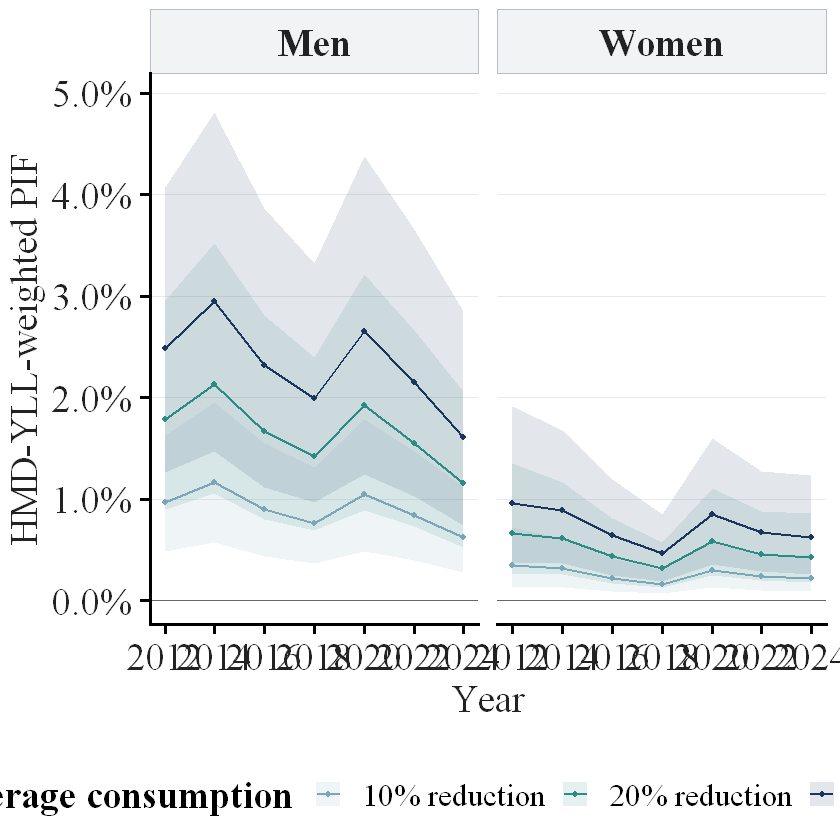

In [8]:
#| label: pif3-figure1-volume-trends
#| fig-width: 7.2
#| fig-height: 4.6
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_fig1_data <- pif3_burden |> dplyr::filter(.data$scenario_id %in% base::names(pif3_volume_colors), .data$applicable, base::is.finite(.data$pif)) |> pif3_weighted_pif("yll_hmd", c("year", "sex_label", "scenario_id")) |> dplyr::mutate(scenario_id = base::factor(.data$scenario_id, levels = base::names(pif3_volume_colors)))
pif3_fig1 <- ggplot2::ggplot(pif3_fig1_data, ggplot2::aes(x = .data$year, y = .data$pif, colour = .data$scenario_id, fill = .data$scenario_id, group = .data$scenario_id)) + ggplot2::geom_hline(yintercept = 0, colour = "#666666", linewidth = 0.35) + ggplot2::geom_ribbon(ggplot2::aes(ymin = .data$pif_low, ymax = .data$pif_up), alpha = 0.12, colour = NA) + ggplot2::geom_line(linewidth = 0.8) + ggplot2::geom_point(size = 1.7, stroke = 0) + ggplot2::facet_wrap(ggplot2::vars(.data$sex_label), nrow = 1) + ggplot2::scale_x_continuous(breaks = base::sort(base::unique(pif3_fig1_data$year))) + ggplot2::scale_y_continuous(labels = scales::label_percent(accuracy = 0.1), expand = ggplot2::expansion(mult = c(0.05, 0.08))) + ggplot2::scale_colour_manual(values = pif3_volume_colors, labels = c("10% reduction", "20% reduction", "30% reduction"), name = "Average consumption") + ggplot2::scale_fill_manual(values = pif3_volume_colors, labels = c("10% reduction", "20% reduction", "30% reduction"), name = "Average consumption") + ggplot2::labs(x = "Year", y = "HMD-YLL-weighted PIF") + pif3_theme()
pif3_fig1_preview <- pif3_fig1 + pif3_theme(base_size = 23)
base::print(pif3_fig1_preview)  # readable in the notebook
pif3_save_plot(pif3_fig1, "figure1_volume_pif_trends", width = 7.2, height = 4.6)
base::message(base::sprintf("pif3-figure1-volume-trends elapsed minutes: %.2f", pif3_elapsed_min(.t0)))

### Figure 2

**Cause-specific burden-weighted PIF for a 30% reduction in average consumption in 2024.** Points summarize the four age groups using HMD YLL as weights; horizontal intervals aggregate the corresponding cell-level lower and upper limits. The vertical reference at zero makes increases in modeled burden visible. A negative PIF means that the counterfactual distribution has greater modeled risk than the observed distribution for that cause-sex combination.


[export] Saved: figure2_cause_specific_pif_2024.tiff and figure2_cause_specific_pif_2024.pdf.



pif3-figure2-cause-pif elapsed minutes: 0.02



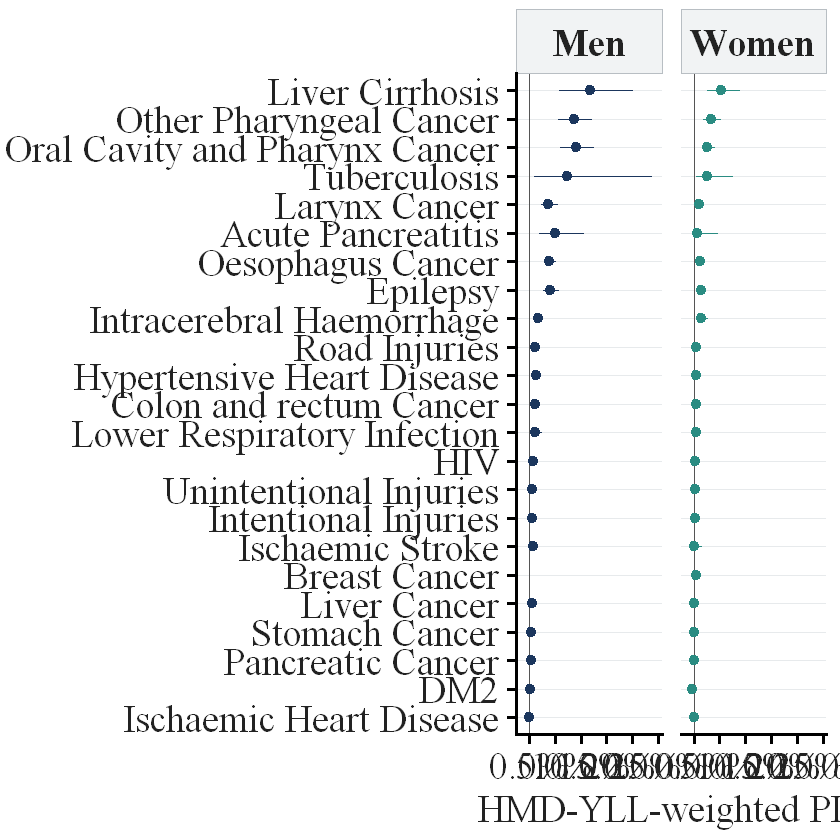

In [9]:
#| label: pif3-figure2-cause-pif
#| fig-width: 8.2
#| fig-height: 7.2
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_fig2_source <- pif3_burden |> dplyr::filter(.data$year == 2024L, .data$scenario_id == "volume_reduction_30", .data$applicable, base::is.finite(.data$pif))
pif3_fig2_data <- pif3_fig2_source |> pif3_weighted_pif("yll_hmd", c("disease", "sex_label", "cause_category"))
pif3_fig2_order <- pif3_fig2_source |> pif3_weighted_pif("yll_hmd", c("disease")) |> dplyr::arrange(.data$pif) |> dplyr::pull(.data$disease)
pif3_fig2_data <- pif3_fig2_data |> dplyr::mutate(disease = base::factor(.data$disease, levels = pif3_fig2_order))
pif3_fig2 <- ggplot2::ggplot(pif3_fig2_data, ggplot2::aes(y = .data$disease, colour = .data$sex_label)) + ggplot2::geom_vline(xintercept = 0, colour = "#555555", linewidth = 0.4) + ggplot2::geom_segment(ggplot2::aes(x = .data$pif_low, xend = .data$pif_up, yend = .data$disease), linewidth = 0.45) + ggplot2::geom_point(ggplot2::aes(x = .data$pif), size = 2.0) + ggplot2::facet_wrap(ggplot2::vars(.data$sex_label), nrow = 1) + ggplot2::scale_x_continuous(labels = scales::label_percent(accuracy = 0.1), expand = ggplot2::expansion(mult = c(0.08, 0.08))) + ggplot2::scale_colour_manual(values = pif3_sex_colors, guide = "none") + ggplot2::labs(x = "HMD-YLL-weighted PIF", y = NULL) + pif3_theme(base_size = 8.5) + ggplot2::theme(panel.grid.major.y = ggplot2::element_line(colour = "#E6E9EB", linewidth = 0.25))
pif3_fig2_preview <- pif3_fig2 + pif3_theme(base_size = 23)
base::print(pif3_fig2_preview)  # readable in the notebook
pif3_save_plot(pif3_fig2, "figure2_cause_specific_pif_2024", width = 8.2, height = 7.2)
base::message(base::sprintf("pif3-figure2-cause-pif elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


### Figure 3

**Expected avoidable deaths and national HMD YLL under a 30% reduction in average consumption in 2024.** Values are summed across sex and age groups. The 12 causes with the largest absolute national avoidable-YLL estimates are shown in both panels. Each percentage is the cause-specific contribution to the net total across all 23 modeled causes for that metric; percentages for the displayed causes therefore need not sum to 100%, and negative contributions are retained.


[export] Saved: figure3_avoidable_deaths_and_hmd_yll_2024.tiff and figure3_avoidable_deaths_and_hmd_yll_2024.pdf.



pif3-figure3-avoidable-burden elapsed minutes: 0.02



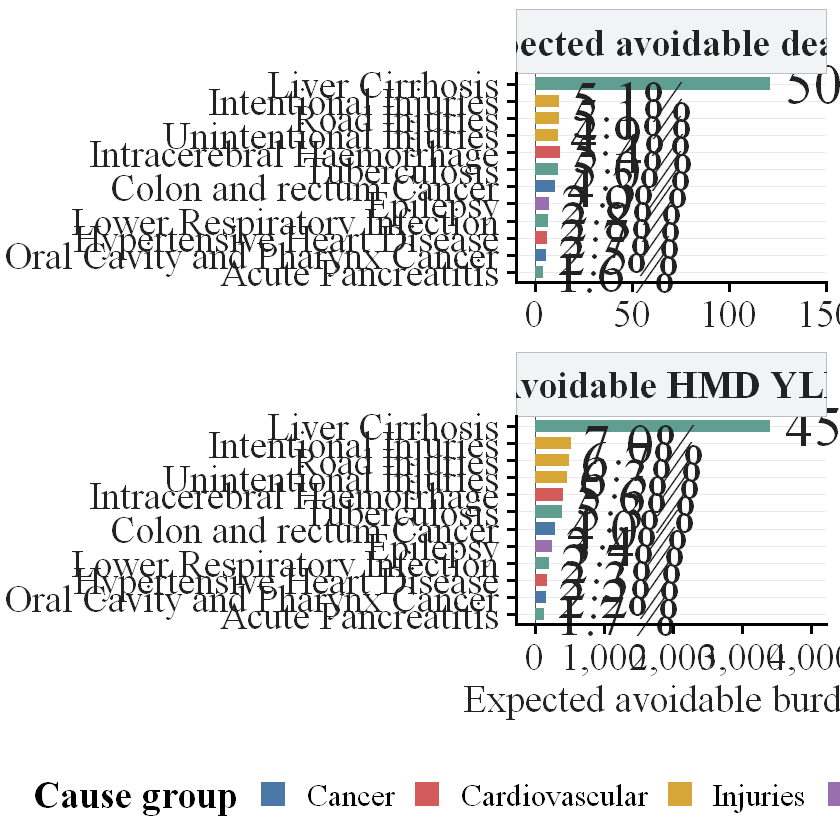

In [10]:
#| label: pif3-figure3-avoidable-burden
#| fig-width: 8.4
#| fig-height: 7.4
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_fig3_wide <- pif3_burden |> dplyr::filter(.data$year == 2024L, .data$scenario_id == "volume_reduction_30", .data$applicable, base::is.finite(.data$pif)) |> dplyr::group_by(.data$disease, .data$cause_category) |> dplyr::summarise(avoidable_deaths = base::sum(.data$avoidable_deaths), avoidable_yll_hmd = base::sum(.data$avoidable_yll_hmd), .groups = "drop")
# Calculate net denominators over every modeled cause before selecting the 12 causes displayed in the figure.
pif3_fig3_totals <- tibble::tibble(metric = c("Expected avoidable deaths", "Avoidable HMD YLL"), total_value = c(base::sum(pif3_fig3_wide$avoidable_deaths), base::sum(pif3_fig3_wide$avoidable_yll_hmd)))
pif3_fig3_top <- pif3_fig3_wide |> dplyr::mutate(rank_value = base::abs(.data$avoidable_yll_hmd)) |> dplyr::slice_max(order_by = .data$rank_value, n = 12L, with_ties = FALSE) |> dplyr::arrange(.data$avoidable_yll_hmd) |> dplyr::pull(.data$disease)
pif3_fig3_data <- pif3_fig3_wide |> dplyr::filter(.data$disease %in% pif3_fig3_top) |> tidyr::pivot_longer(cols = c("avoidable_deaths", "avoidable_yll_hmd"), names_to = "metric", values_to = "value") |> dplyr::mutate(disease = base::factor(.data$disease, levels = pif3_fig3_top), metric = dplyr::recode(.data$metric, "avoidable_deaths" = "Expected avoidable deaths", "avoidable_yll_hmd" = "Avoidable HMD YLL")) |> dplyr::left_join(pif3_fig3_totals, by = "metric") |> dplyr::mutate(metric = base::factor(.data$metric, levels = c("Expected avoidable deaths", "Avoidable HMD YLL")), contribution_pct = 100 * .data$value / .data$total_value, contribution_label = base::sprintf("%.1f%%", .data$contribution_pct), label_hjust = dplyr::if_else(.data$value >= 0, -0.10, 1.10))
pif3_fig3 <- ggplot2::ggplot(pif3_fig3_data, ggplot2::aes(x = .data$value, y = .data$disease, fill = .data$cause_category)) + ggplot2::geom_vline(xintercept = 0, colour = "#555555", linewidth = 0.4) + ggplot2::geom_col(width = 0.72) + ggplot2::facet_wrap(ggplot2::vars(.data$metric), ncol = 1, scales = "free_x") + ggplot2::scale_x_continuous(labels = scales::label_number(accuracy = 1, big.mark = ","), expand = ggplot2::expansion(mult = c(0.08, 0.24))) + ggplot2::scale_fill_manual(values = pif3_cause_colors, name = "Cause group") + ggplot2::labs(x = "Expected avoidable burden", y = NULL) + ggplot2::coord_cartesian(clip = "off") + pif3_theme(base_size = 8.5)
pif3_fig3_preview <- pif3_fig3 + pif3_theme(base_size = 23)+ ggplot2::geom_text(ggplot2::aes(label = .data$contribution_label, hjust = .data$label_hjust), family = pif3_font_family, size = 12, colour = "#222222") 
base::print(pif3_fig3_preview)  # readable in the notebook
pif3_save_plot(pif3_fig3+ ggplot2::geom_text(ggplot2::aes(label = .data$contribution_label, hjust = .data$label_hjust), family = pif3_font_family, size = 2.65, colour = "#222222"), "figure3_avoidable_deaths_and_hmd_yll_2024", width = 8.4, height = 7.4)
base::message(base::sprintf("pif3-figure3-avoidable-burden elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


### Figures 3A and 3B

**Age-group and sex decomposition of expected avoidable burden under a 30% reduction in average consumption in 2024.** Stacked segments represent broad cause groups and labels show the net burden across all modeled causes within each age-group and sex stratum. Figure 3A reports deaths; Figure 3B reports national HMD YLL. Negative cause-group contributions are retained.


[export] Saved: pif3-figure3a-age-sex-deaths.tiff and pif3-figure3a-age-sex-deaths.pdf.



pif3-figure3a-age-sex-deaths elapsed minutes: 0.02



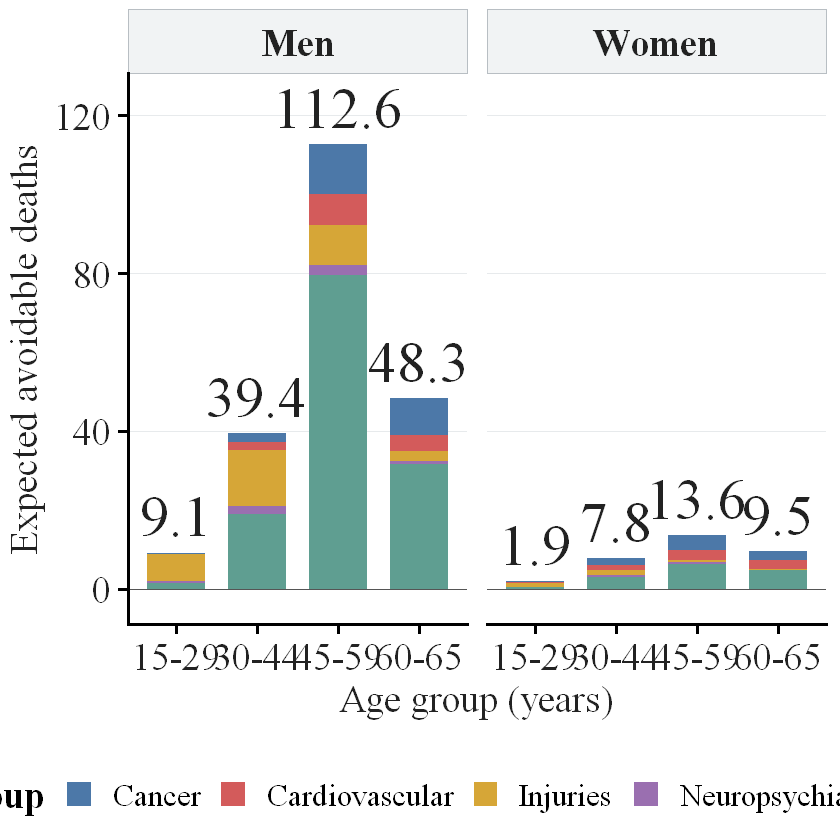

In [11]:
#| label: pif3-figure3a-age-sex-deaths
#| fig-width: 8.2
#| fig-height: 4.8
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_fig3a_data <- pif3_burden |> dplyr::filter(.data$year == 2024L, .data$scenario_id == "volume_reduction_30", .data$applicable, base::is.finite(.data$pif)) |> dplyr::group_by(.data$sex_label, .data$age_label, .data$cause_category) |> dplyr::summarise(value = base::sum(.data$avoidable_deaths), .groups = "drop") |> dplyr::mutate(age_label = base::factor(.data$age_label, levels = base::unname(pif3_age_labels)))
pif3_fig3a_totals <- pif3_fig3a_data |> dplyr::group_by(.data$sex_label, .data$age_label) |> dplyr::summarise(total = base::sum(.data$value), .groups = "drop")
pif3_fig3a <- ggplot2::ggplot(pif3_fig3a_data, ggplot2::aes(x = .data$age_label, y = .data$value, fill = .data$cause_category)) + ggplot2::geom_hline(yintercept = 0, colour = "#555555", linewidth = 0.35) + ggplot2::geom_col(width = 0.72) + ggplot2::facet_wrap(ggplot2::vars(.data$sex_label), nrow = 1) + ggplot2::scale_y_continuous(labels = scales::label_number(accuracy = 1, big.mark = ","), expand = ggplot2::expansion(mult = c(0.08, 0.16))) + ggplot2::scale_fill_manual(values = pif3_cause_colors, name = "Cause group") + ggplot2::labs(x = "Age group (years)", y = "Expected avoidable deaths") + pif3_theme(base_size = 8.5)
pif3_fig3a_preview <- pif3_fig3a + pif3_theme(base_size = 23)+ ggplot2::geom_text(data = pif3_fig3a_totals, ggplot2::aes(x = .data$age_label, y = .data$total, label = scales::number(.data$total, accuracy = 0.1), fill = NULL), vjust = -0.45, family = pif3_font_family, size = 12, colour = "#222222")
base::print(pif3_fig3a_preview)  # readable in the notebook
pif3_save_plot(
  pif3_fig3a +
    ggplot2::geom_text(
      data = pif3_fig3a_totals,
      ggplot2::aes(
        x = .data$age_label,
        y = .data$total,
        label = scales::number(.data$total, accuracy = 0.1),
        fill = NULL
      ),
      vjust = -0.45,
      family = pif3_font_family,
      size = 2.8,
      colour = "#222222"
    ),
  stem = "pif3-figure3a-age-sex-deaths", 
  width = 8.4, 
  height = 7.4
)
base::message(base::sprintf("pif3-figure3a-age-sex-deaths elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[export] Saved: figure3b_avoidable_hmd_yll_age_sex_2024.tiff and figure3b_avoidable_hmd_yll_age_sex_2024.pdf.



pif3-figure3b-age-sex-yll elapsed minutes: 0.02



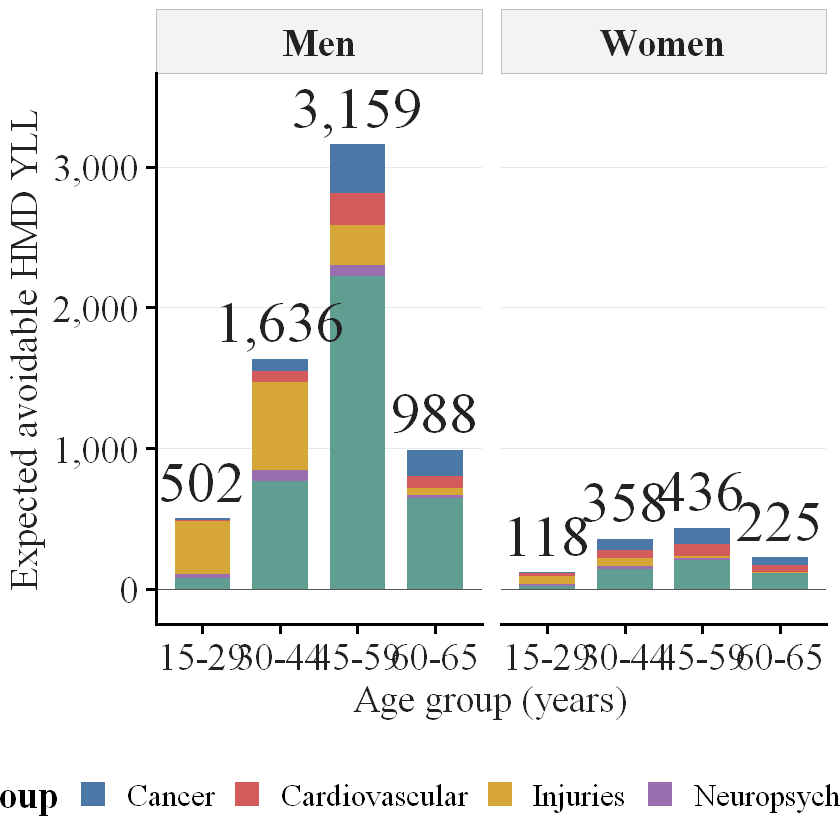

In [12]:
#| label: pif3-figure3b-age-sex-yll
#| fig-width: 8.2
#| fig-height: 4.8
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_fig3b_data <- pif3_burden |> dplyr::filter(.data$year == 2024L, .data$scenario_id == "volume_reduction_30", .data$applicable, base::is.finite(.data$pif)) |> dplyr::group_by(.data$sex_label, .data$age_label, .data$cause_category) |> dplyr::summarise(value = base::sum(.data$avoidable_yll_hmd), .groups = "drop") |> dplyr::mutate(age_label = base::factor(.data$age_label, levels = base::unname(pif3_age_labels)))
pif3_fig3b_totals <- pif3_fig3b_data |> dplyr::group_by(.data$sex_label, .data$age_label) |> dplyr::summarise(total = base::sum(.data$value), .groups = "drop")
pif3_fig3b <- ggplot2::ggplot(pif3_fig3b_data, ggplot2::aes(x = .data$age_label, y = .data$value, fill = .data$cause_category)) + ggplot2::geom_hline(yintercept = 0, colour = "#555555", linewidth = 0.35) + ggplot2::geom_col(width = 0.72) + ggplot2::facet_wrap(ggplot2::vars(.data$sex_label), nrow = 1) + ggplot2::scale_y_continuous(labels = scales::label_number(accuracy = 1, big.mark = ","), expand = ggplot2::expansion(mult = c(0.08, 0.16))) + ggplot2::scale_fill_manual(values = pif3_cause_colors, name = "Cause group") + ggplot2::labs(x = "Age group (years)", y = "Expected avoidable HMD YLL") + pif3_theme(base_size = 8.5)

pif3_fig3b_preview <- pif3_fig3b + pif3_theme(base_size = 23)+ ggplot2::geom_text(data = pif3_fig3b_totals, ggplot2::aes(x = .data$age_label, y = .data$total, label = scales::comma(.data$total, accuracy = 1), fill = NULL), vjust = -0.45, family = pif3_font_family, size = 12, colour = "#222222") 
base::print(pif3_fig3b_preview)  # readable in the notebook

pif3_save_plot(pif3_fig3b+
  ggplot2::geom_text(data = pif3_fig3b_totals, 
    ggplot2::aes(x = .data$age_label, 
      y = .data$total, 
      label = scales::comma(.data$total, accuracy = 1), fill = NULL), 
    vjust = -0.45, 
    family = pif3_font_family, 
    size = 2.8, 
    colour = "#222222"), 
  "figure3b_avoidable_hmd_yll_age_sex_2024", 
width = 8.2, 
height = 4.8)
base::message(base::sprintf("pif3-figure3b-age-sex-yll elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


### Figure 4

**Sensitivity of avoidable years of life lost to the YLL definition.** The same 2024 cause-sex-age PIF values from the 30% average-consumption reduction are multiplied separately by national HMD YLL, GBD standard-life-table YLL, and reference-age YPLL. Lines connect definitions only to facilitate within-sex comparison; the three quantities should never be added together.


[export] Saved: figure4_yll_definition_sensitivity_2024.tiff and figure4_yll_definition_sensitivity_2024.pdf.



pif3-figure4-yll-definitions elapsed minutes: 0.01



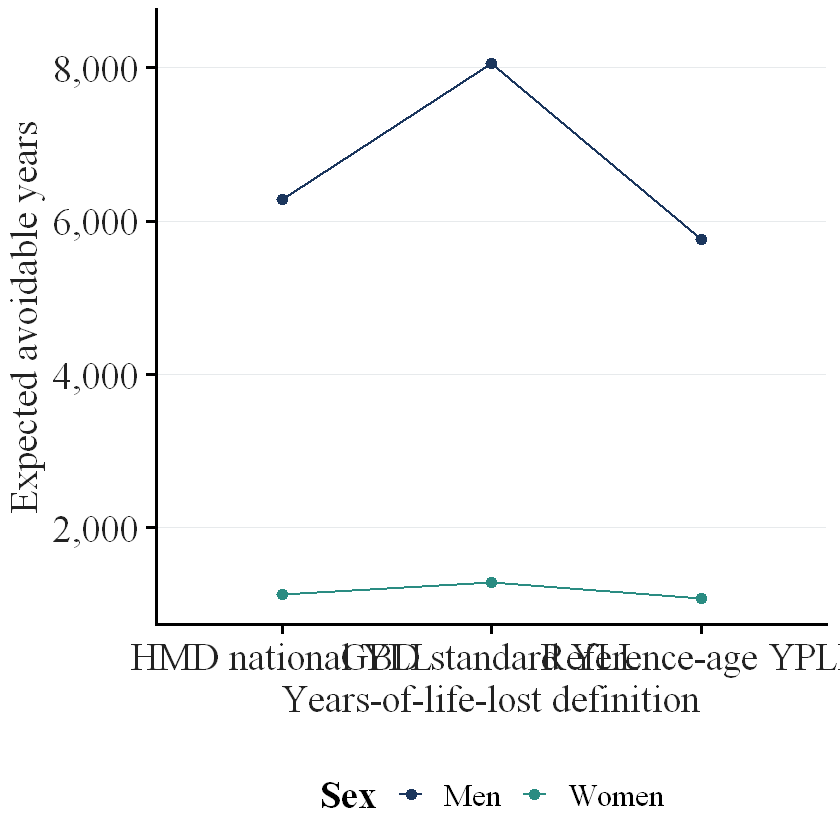

In [13]:
#| label: pif3-figure4-yll-definitions
#| fig-width: 6.8
#| fig-height: 4.5
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_fig4_data <- pif3_burden |> dplyr::filter(.data$year == 2024L, .data$scenario_id == "volume_reduction_30", .data$applicable, base::is.finite(.data$pif)) |> dplyr::group_by(.data$sex_label) |> dplyr::summarise(`HMD national YLL` = base::sum(.data$avoidable_yll_hmd), `GBD standard YLL` = base::sum(.data$avoidable_yll_gbd), `Reference-age YPLL` = base::sum(.data$avoidable_ypll_ref), .groups = "drop") |> tidyr::pivot_longer(cols = -c("sex_label"), names_to = "metric", values_to = "avoidable_years") |> dplyr::mutate(metric = base::factor(.data$metric, levels = c("HMD national YLL", "GBD standard YLL", "Reference-age YPLL")))
pif3_fig4 <- ggplot2::ggplot(pif3_fig4_data, ggplot2::aes(x = .data$metric, y = .data$avoidable_years, colour = .data$sex_label, group = .data$sex_label)) + ggplot2::geom_line(linewidth = 0.7) + ggplot2::geom_point(size = 2.5) + ggplot2::scale_y_continuous(labels = scales::label_number(accuracy = 1, big.mark = ","), expand = ggplot2::expansion(mult = c(0.05, 0.10))) + ggplot2::scale_colour_manual(values = pif3_sex_colors, name = "Sex") + ggplot2::labs(x = "Years-of-life-lost definition", y = "Expected avoidable years") + pif3_theme() + ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 18, hjust = 1))
pif3_fig4_preview <- pif3_fig4 + pif3_theme(base_size = 23)

base::print(pif3_fig4_preview)
pif3_save_plot(pif3_fig4, "figure4_yll_definition_sensitivity_2024", width = 6.8, height = 4.5)
base::message(base::sprintf("pif3-figure4-yll-definitions elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


### Figure 5

**Injury PIF under reductions in HED prevalence, comparing ex-HED assignment rules in 2024.** Estimates come from the independently generated full injuries test artifact and are weighted across age groups by HMD YLL. “No shift” retains the exiting HED group's own consumption density; “Complete shift” assigns that mass to the NHED distribution. Complete-shift estimates are displaced slightly to the right and no-shift estimates slightly to the left solely to prevent graphical overlap. Intervals aggregate age-specific cell-level limits.


[export] Saved: figure5_injury_hed_exit_rules_2024.tiff and figure5_injury_hed_exit_rules_2024.pdf.



pif3-figure5-injury-exit-rules elapsed minutes: 0.02



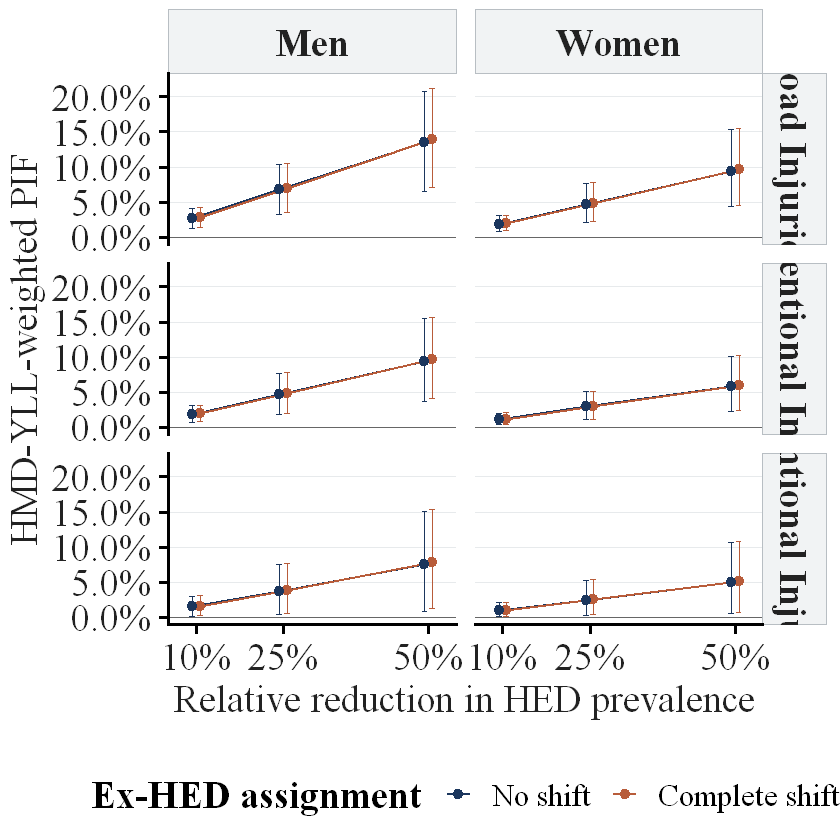

In [14]:
#| label: pif3-figure5-injury-exit-rules
#| fig-width: 8.4
#| fig-height: 7.0
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_fig5_data <- pif3_injury_burden |> dplyr::filter(.data$year == 2024L, .data$engine_scenario == "hed", .data$scenario_id != "baseline", .data$applicable, base::is.finite(.data$pif)) |> pif3_weighted_pif("yll_hmd", c("disease", "sex_label", "exit_rule", "hed_prevalence_change_pct")) |> dplyr::mutate(exit_rule = base::factor(.data$exit_rule, levels = c("No shift", "Complete shift")), disease = base::factor(.data$disease, levels = c("Road Injuries", "Unintentional Injuries", "Intentional Injuries")), x_display = .data$hed_prevalence_change_pct + dplyr::if_else(.data$exit_rule == "Complete shift", 0.65, -0.65))
pif3_fig5 <- ggplot2::ggplot(pif3_fig5_data, ggplot2::aes(x = .data$x_display, y = .data$pif, colour = .data$exit_rule, group = .data$exit_rule)) + ggplot2::geom_hline(yintercept = 0, colour = "#666666", linewidth = 0.35) + ggplot2::geom_line(linewidth = 0.75) + ggplot2::geom_errorbar(ggplot2::aes(ymin = .data$pif_low, ymax = .data$pif_up), width = 1.0, linewidth = 0.4) + ggplot2::geom_point(size = 2.0) + ggplot2::facet_grid(rows = ggplot2::vars(.data$disease), cols = ggplot2::vars(.data$sex_label)) + ggplot2::scale_x_continuous(breaks = c(10, 25, 50), labels = scales::label_number(suffix = "%"), limits = c(7.5, 52.5)) + ggplot2::scale_y_continuous(labels = scales::label_percent(accuracy = 0.1), expand = ggplot2::expansion(mult = c(0.05, 0.10))) + ggplot2::scale_colour_manual(values = pif3_exit_colors, name = "Ex-HED assignment") + ggplot2::labs(x = "Relative reduction in HED prevalence", y = "HMD-YLL-weighted PIF") + pif3_theme(base_size = 8.5)
pif3_fig5_preview <- pif3_fig5 + pif3_theme(base_size = 23)
base::print(pif3_fig5_preview)
pif3_save_plot(pif3_fig5, "figure5_injury_hed_exit_rules_2024", width = 8.4, height = 7.0)
base::message(base::sprintf("pif3-figure5-injury-exit-rules elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


## Supplementary diagnostic figure

### Figure S1

**Applicability of the 16 modeled policy scenarios by cause.** Dark cells indicate that a PIF is defined by the relative-risk structure for that cause; light cells indicate that the scenario is not applicable. HED-only and combined scenarios are unavailable for volume-only causes and remain missing in all analytical summaries.


[export] Saved: figureS1_scenario_applicability.tiff and figureS1_scenario_applicability.pdf.



pif3-figure-s1-applicability elapsed minutes: 0.01



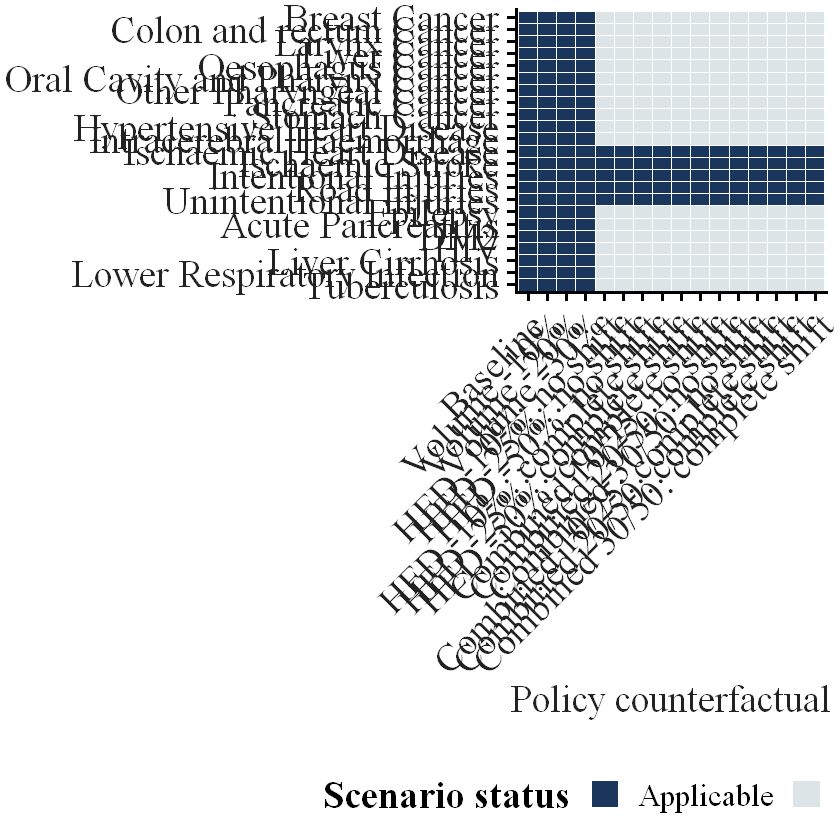

In [15]:
#| label: pif3-figure-s1-applicability
#| fig-width: 10.5
#| fig-height: 7.6
#| fig-dpi: 300
.t0 <- Sys.time()
pif3_figs1_data <- pif3_pif_results |> dplyr::group_by(.data$disease, .data$scenario_id) |> dplyr::summarise(applicable = base::all(.data$applicable), .groups = "drop") |> dplyr::left_join(pif3_scenario_metadata |> dplyr::select(dplyr::all_of(c("scenario_id", "scenario_short", "scenario_order"))), by = "scenario_id") |> dplyr::mutate(cause_category = pif3_cause_category(.data$disease), scenario_short = base::factor(.data$scenario_short, levels = pif3_scenario_metadata |> dplyr::arrange(.data$scenario_order) |> dplyr::pull(.data$scenario_short)))
pif3_figs1_disease_order <- pif3_figs1_data |> dplyr::distinct(.data$disease, .data$cause_category) |> dplyr::arrange(base::factor(.data$cause_category, levels = c("Cancer", "Cardiovascular", "Injuries", "Neuropsychiatric", "Other causes")), .data$disease) |> dplyr::pull(.data$disease)
pif3_figs1_data <- pif3_figs1_data |> dplyr::mutate(disease = base::factor(.data$disease, levels = base::rev(pif3_figs1_disease_order)), applicability = dplyr::if_else(.data$applicable, "Applicable", "Not applicable"))
pif3_figs1 <- ggplot2::ggplot(pif3_figs1_data, ggplot2::aes(x = .data$scenario_short, y = .data$disease, fill = .data$applicability)) + ggplot2::geom_tile(colour = "white", linewidth = 0.3) + ggplot2::scale_fill_manual(values = c("Applicable" = pif3_palette[["navy"]], "Not applicable" = pif3_palette[["pale"]]), name = "Scenario status") + ggplot2::labs(x = "Policy counterfactual", y = NULL) + pif3_theme(base_size = 7.5) + ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 45, hjust = 1, vjust = 1), panel.grid = ggplot2::element_blank())

pif3_figs1_preview <- pif3_figs1 + pif3_theme(base_size = 23)+ ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 45, hjust = 1))  # 45°  turn
base::print(pif3_figs1_preview)
pif3_save_plot(pif3_figs1, "figureS1_scenario_applicability", width = 10.5, height = 7.6)
base::message(base::sprintf("pif3-figure-s1-applicability elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


## Supplementary tables

**Table S1. Avoidable YPLL rate (per 100,000 person-years) and 95% uncertainty limits by sex and counterfactual scenario, 2012–2024.** Numerators and projected-population denominators are pooled across the seven modeled years. Only cause-scenario cells marked applicable by the upstream engine are included.

**Table S2. Median annual alcohol-attributable deaths by cause group, sex, and age group, 2012–2024.** Annual cause-specific estimates are first summed within broad cause groups, then the median across the seven modeled years is reported. Fully alcohol-attributable causes are retained as a distinct group.

**Table S3. Total expected avoidable deaths by cause, counterfactual scenario, and age group, 2012–2024.** Estimates are summed over sex and the seven modeled years. Structurally non-applicable cause-scenario combinations are omitted.

For all three tables, lower and upper values are aggregated cell-level limits and should be described as uncertainty envelopes unless synchronized simulation draws are propagated upstream.


In [16]:
#| label: pif3-supplementary-table-helpers
#| results: "hold"
.t0 <- Sys.time()
pif3_table_dir <- base::file.path(pif3_dirs$control, "tables_expand_pif3")
base::dir.create(pif3_table_dir, recursive = TRUE, showWarnings = FALSE)
pif3_write_table <- function(data, filename) {
  path <- base::file.path(pif3_table_dir, filename)
  utils::write.csv(data, path, row.names = FALSE, na = "")
  pif3_message("[table export] Saved %d rows: %s.", base::nrow(data), path)
  invisible(path)
}
pif3_show_table <- function(data, caption, digits = 1L) {
  htmltools::browsable(
    htmltools::div(
      style = "max-height: 520px; overflow-y: auto; overflow-x: auto;",
      htmltools::HTML(
        knitr::kable(
          data,
          format = "html",
          digits = digits,
          caption = caption,
          escape = TRUE
        )
      )
    )
  )
}

base::message(base::sprintf("pif3-supplementary-table-helpers elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


pif3-supplementary-table-helpers elapsed minutes: 0.00



In [17]:
#| label: pif3-table-s1-ypll-rate
#| results: "asis"
.t0 <- Sys.time()
# Pool avoidable HMD YLL and person-years across modeled years to avoid averaging annual rates with unequal denominators.
pif3_table_s1_numerator <- pif3_burden |> dplyr::filter(.data$applicable, base::is.finite(.data$pif)) |> dplyr::group_by(.data$sex, .data$sex_label, .data$scenario_id, .data$scenario_short, .data$scenario_order) |> dplyr::summarise(avoidable_ypll = base::sum(.data$avoidable_yll_hmd), lower = base::sum(.data$avoidable_yll_hmd_low), upper = base::sum(.data$avoidable_yll_hmd_up), applicable_causes = dplyr::n_distinct(.data$disease), .groups = "drop")
pif3_table_s1_denominator <- pif3_population_sex_year |> dplyr::group_by(.data$sex, .data$sex_label) |> dplyr::summarise(person_years = base::sum(.data$population), .groups = "drop")
pif3_table_s1 <- pif3_table_s1_numerator |> dplyr::left_join(pif3_table_s1_denominator, by = c("sex", "sex_label")) |> dplyr::mutate(rate_per_100000 = 100000 * .data$avoidable_ypll / .data$person_years, lower_per_100000 = 100000 * .data$lower / .data$person_years, upper_per_100000 = 100000 * .data$upper / .data$person_years, modelled_years = base::length(pif3_modelled_years)) |> dplyr::arrange(.data$scenario_order, .data$sex_label) |> dplyr::transmute(Sex = .data$sex_label, Scenario = .data$scenario_short, `Avoidable YPLL rate per 100,000` = .data$rate_per_100000, `Lower 95% uncertainty limit` = .data$lower_per_100000, `Upper 95% uncertainty limit` = .data$upper_per_100000, `Applicable causes` = .data$applicable_causes, `Modeled years` = .data$modelled_years)
pif3_write_table(pif3_table_s1, "tableS1_avoidable_ypll_rate_by_sex_scenario_2012_2024.csv")
pif3_show_table(pif3_table_s1, "Table S1. Avoidable YPLL rate per 100,000 person-years by sex and counterfactual scenario, 2012-2024.", digits = 1L)
base::message(base::sprintf("pif3-table-s1-ypll-rate elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[table export] Saved 32 rows: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/tables_expand_pif3/tableS1_avoidable_ypll_rate_by_sex_scenario_2012_2024.csv.



Sex,Scenario,"Avoidable YPLL rate per 100,000",Lower 95% uncertainty limit,Upper 95% uncertainty limit,Applicable causes,Modeled years
Men,Baseline,0.0,0.0,0.0,22,7
Women,Baseline,0.0,0.0,0.0,23,7
Men,Volume -10%,52.0,24.8,89.3,22,7
Women,Volume -10%,6.3,2.6,12.3,23,7
Men,Volume -20%,95.8,46.1,162.0,22,7
Women,Volume -20%,12.3,5.0,23.7,23,7
Men,Volume -30%,133.4,64.5,222.5,22,7
Women,Volume -30%,17.9,7.3,34.2,23,7
Men,HED -10%: no shift,69.7,25.0,115.5,5,7
Women,HED -10%: no shift,10.0,3.4,18.0,5,7


pif3-table-s1-ypll-rate elapsed minutes: 0.00



In [18]:
#| label: pif3-table-s2-attributable-deaths
#| results: "asis"
.t0 <- Sys.time()
# Aggregate causes within each year before taking the median, so the statistic represents a median annual group total.
pif3_table_s2_annual <- pif3_mortality |> dplyr::group_by(.data$year, .data$cause_group, .data$sex_label, .data$age_group, .data$age_label) |> dplyr::summarise(deaths = base::sum(.data$mort), lower = base::sum(.data$ll_mort), upper = base::sum(.data$up_mort), .groups = "drop")
pif3_table_s2 <- pif3_table_s2_annual |> dplyr::group_by(.data$cause_group, .data$sex_label, .data$age_group, .data$age_label) |> dplyr::summarise(median_annual_deaths = stats::median(.data$deaths), lower = stats::median(.data$lower), upper = stats::median(.data$upper), modelled_years = dplyr::n_distinct(.data$year), .groups = "drop") |> dplyr::arrange(.data$cause_group, .data$sex_label, .data$age_group) |> dplyr::transmute(`Cause group` = .data$cause_group, Sex = .data$sex_label, `Age group (years)` = .data$age_label, `Median annual alcohol-attributable deaths` = .data$median_annual_deaths, `Lower 95% uncertainty limit` = .data$lower, `Upper 95% uncertainty limit` = .data$upper, `Modeled years` = .data$modelled_years)
pif3_write_table(pif3_table_s2, "tableS2_median_annual_alcohol_attributable_deaths_2012_2024.csv")
pif3_show_table(pif3_table_s2, "Table S2. Median annual alcohol-attributable deaths by cause group, sex, and age group, 2012-2024.", digits = 1L)
base::message(base::sprintf("pif3-table-s2-attributable-deaths elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[table export] Saved 48 rows: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/tables_expand_pif3/tableS2_median_annual_alcohol_attributable_deaths_2012_2024.csv.



Cause group,Sex,Age group (years),Median annual alcohol-attributable deaths,Lower 95% uncertainty limit,Upper 95% uncertainty limit,Modeled years
Cancer,Men,15-29,3.7,2.7,4.7,7
Cancer,Men,30-44,27.3,20.3,34.7,7
Cancer,Men,45-59,160.7,107.4,215.4,7
Cancer,Men,60-65,149.4,85.4,213.5,7
Cancer,Women,15-29,1.5,0.4,2.3,7
Cancer,Women,30-44,17.6,6.3,28.4,7
Cancer,Women,45-59,84.2,30.2,145.4,7
Cancer,Women,60-65,78.4,24.7,128.8,7
Cardiovascular,Men,15-29,3.4,0.9,6.5,7
Cardiovascular,Men,30-44,23.0,7.6,39.3,7


pif3-table-s2-attributable-deaths elapsed minutes: 0.00



In [19]:
#| label: pif3-table-s3-avoidable-deaths
#| results: "asis"
.t0 <- Sys.time()
# Sum expected avoidable deaths over sex and modeled years while preserving cause, scenario, and age group.
pif3_table_s3 <- pif3_burden |> dplyr::filter(.data$applicable, base::is.finite(.data$pif)) |> dplyr::group_by(.data$disease, .data$cause_category, .data$scenario_id, .data$scenario_short, .data$scenario_order, .data$age_group, .data$age_label) |> dplyr::summarise(total_avoidable_deaths = base::sum(.data$avoidable_deaths), lower = base::sum(.data$avoidable_deaths_low), upper = base::sum(.data$avoidable_deaths_up), contributing_cells = dplyr::n(), .groups = "drop") |> dplyr::arrange(.data$scenario_order, .data$disease, .data$age_group) |> dplyr::transmute(Cause = .data$disease, `Cause group` = .data$cause_category, Scenario = .data$scenario_short, `Age group (years)` = .data$age_label, `Total expected avoidable deaths` = .data$total_avoidable_deaths, `Lower 95% uncertainty limit` = .data$lower, `Upper 95% uncertainty limit` = .data$upper, `Contributing cells` = .data$contributing_cells)

pif3_write_table(pif3_table_s3, "tableS3_total_avoidable_deaths_by_cause_scenario_age_2012_2024.csv")
pif3_show_table(pif3_table_s3, "Table S3. Total expected avoidable deaths by cause, counterfactual scenario, and age group, 2012-2024.", digits = 1L)
base::message(base::sprintf("pif3-table-s3-avoidable-deaths elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[table export] Saved 604 rows: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/tables_expand_pif3/tableS3_total_avoidable_deaths_by_cause_scenario_age_2012_2024.csv.



Cause,Cause group,Scenario,Age group (years),Total expected avoidable deaths,Lower 95% uncertainty limit,Upper 95% uncertainty limit,Contributing cells
Acute Pancreatitis,Other causes,Baseline,15-29,0.0,0.0,0.0,13
Acute Pancreatitis,Other causes,Baseline,30-44,0.0,0.0,0.0,14
Acute Pancreatitis,Other causes,Baseline,45-59,0.0,0.0,0.0,14
Acute Pancreatitis,Other causes,Baseline,60-65,0.0,0.0,0.0,14
Breast Cancer,Cancer,Baseline,15-29,0.0,0.0,0.0,7
Breast Cancer,Cancer,Baseline,30-44,0.0,0.0,0.0,7
Breast Cancer,Cancer,Baseline,45-59,0.0,0.0,0.0,7
Breast Cancer,Cancer,Baseline,60-65,0.0,0.0,0.0,7
Colon and rectum Cancer,Cancer,Baseline,15-29,0.0,0.0,0.0,14
Colon and rectum Cancer,Cancer,Baseline,30-44,0.0,0.0,0.0,14


pif3-table-s3-avoidable-deaths elapsed minutes: 0.00



## Reporting notes for a manuscript

- Report the intervention as a **relative reduction** in average consumption or HED prevalence, not as a percentage-point reduction.
- State the ex-HED assignment rule whenever an HED or combined scenario is reported; this notebook uses the concise labels “No shift” and “Complete shift”.
- Use HMD YLL for national estimates and GBD YLL for international comparability; do not mix or sum the definitions.
- Describe negative PIFs as modeled increases in burden under the counterfactual and retain them in totals.
- Describe non-applicable HED scenarios as structurally undefined for volume-only causes, not as null effects.
- Interpret “2012–2024” summaries as the seven complete modeled years listed above.
- If aggregate 95% uncertainty intervals are required for a manuscript, rerun the engine while retaining synchronized simulation draws across cells. The summed limits in this notebook are descriptive envelopes, not a substitute for joint propagation.

The visual conventions are compatible with a restrained epidemiology-journal style: high contrast, no decorative backgrounds, limited colors, direct units, 600-dpi TIFF exports, and vector PDF companions.


In [20]:
#| label: pif3-output-manifest
#| results: "hold"
.t0 <- Sys.time()
pif3_exported_figures <- if (base::dir.exists(pif3_figure_dir)) base::list.files(pif3_figure_dir, pattern = "\\.(tiff|pdf)$", full.names = TRUE) else character(0)
pif3_exported_tables <- if (base::exists("pif3_table_dir") && base::dir.exists(pif3_table_dir)) base::list.files(pif3_table_dir, pattern = "\\.csv$", full.names = TRUE) else character(0)
pif3_exported_files <- c(pif3_exported_figures, pif3_exported_tables)
pif3_manifest <- if (base::length(pif3_exported_files)) {
  pif3_info <- base::file.info(pif3_exported_files)
  tibble::tibble(artifact = dplyr::if_else(base::tolower(tools::file_ext(pif3_exported_files)) == "csv", "Table", "Figure"), file = base::basename(pif3_exported_files), format = base::toupper(tools::file_ext(pif3_exported_files)), size_kb = base::round(pif3_info$size / 1024, 1), modified = pif3_info$mtime) |> dplyr::arrange(.data$artifact, .data$file)
} else {
  tibble::tibble(artifact = character(0), file = character(0), format = character(0), size_kb = numeric(0), modified = as.POSIXct(character(0)))
}
base::print(knitr::kable(pif3_manifest, format = "simple", caption = "Exported publication figures and supplementary tables"))
pif3_message("[manifest] %d exported files available across the figure and table directories.", base::nrow(pif3_manifest))
base::message(base::sprintf("pif3-output-manifest elapsed minutes: %.2f", pif3_elapsed_min(.t0)))




Table: Exported publication figures and supplementary tables

artifact   file                                                                 format    size_kb  modified            
---------  -------------------------------------------------------------------  -------  --------  --------------------
Figure     figure1_volume_pif_trends.pdf                                        PDF          40.6  2026-07-21 09:44:11 
Figure     figure1_volume_pif_trends.tiff                                       TIFF        513.6  2026-07-21 09:44:11 
Figure     figure2_cause_specific_pif_2024.pdf                                  PDF          46.7  2026-07-21 09:44:12 
Figure     figure2_cause_specific_pif_2024.tiff                                 TIFF        476.7  2026-07-21 09:44:12 
Figure     figure3_avoidable_deaths_and_hmd_yll_2024.pdf                        PDF          50.2  2026-07-21 09:44:14 
Figure     figure3_avoidable_deaths_and_hmd_yll_2024.tiff                       TIFF        598.

[manifest] 32 exported files available across the figure and table directories.



pif3-output-manifest elapsed minutes: 0.00



## Table 5 (Chile 2014, PUC) IHD/IS relative-risk

In [21]:
#| label: pif3-load-table5

.t0 <- Sys.time()
# The Table 5 (Chile 2014, PUC) IHD/IS relative-risk experiment is written by
# expand_pif2.ipynb under its own dated stem, so the main-grid selector cannot pick
# it up by accident. Both grids come from the same engine, the same scenario grid,
# and the same Monte Carlo configuration; only the IHD/IS RR functions differ.
pif3_table5_path <- pif3_latest_dated_file(pif3_dirs$control, "pif2_pif_results_table5_full")
pif3_table5_results <- pif3_read_rds(pif3_table5_path)
pif3_table5_diseases <- c("Ischaemic Heart Disease", "Ischaemic Stroke")
# Columns produced only by the Table 5 run. They would collide with the exit_rule that
# pif3_scenario_metadata derives from scenario_id, so they are dropped before enrichment.
pif3_table5_run_columns <- c("hed_exit_mix", "hed_exit_shift", "exit_rule", "scale",
                             "rr_source", "policy_vol_lever_pct", "implied_vol_change_pct")
pif3_cv_keys <- c("disease", "sex", "age_group", "year", "scenario_id")
pif3_cv_main_raw <- pif3_pif_results |>
  tibble::as_tibble() |>
  dplyr::filter(.data$disease %in% pif3_table5_diseases)
pif3_cv_table5_raw <- pif3_table5_results |> tibble::as_tibble()
pif3_key_vector <- function(data) {
  # Compare key sets as sorted text. pif3_read_rds attaches a "path" attribute that
  # survives dplyr verbs, so identical() on data frames would compare provenance, not keys.
  base::sort(base::do.call(base::paste, c(data[pif3_cv_keys], sep = "|")))
}
pif3_cv_applicable_t5 <- pif3_cv_table5_raw$applicable & base::is.finite(pif3_cv_table5_raw$pif)
pif3_table5_report <- tibble::tibble(
  check = c("table5_expected_diseases", "table5_unique_keys", "table5_keys_match_main",
            "table5_scenarios_match", "table5_years_match", "table5_nsim_match",
            "table5_applicability_matches", "table5_interval_ordering",
            "table5_baseline_is_zero", "table5_rr_source_labelled"),
  pass = c(
    base::setequal(base::unique(pif3_cv_table5_raw$disease), pif3_table5_diseases),
    base::anyDuplicated(pif3_cv_table5_raw[pif3_cv_keys]) == 0L,
    base::identical(pif3_key_vector(pif3_cv_main_raw), pif3_key_vector(pif3_cv_table5_raw)),
    base::setequal(base::unique(pif3_cv_main_raw$scenario_id), base::unique(pif3_cv_table5_raw$scenario_id)),
    base::setequal(base::unique(pif3_cv_main_raw$year), base::unique(pif3_cv_table5_raw$year)),
    base::setequal(base::unique(pif3_cv_main_raw$n_sim), base::unique(pif3_cv_table5_raw$n_sim)),
    base::sum(pif3_cv_main_raw$applicable) == base::sum(pif3_cv_table5_raw$applicable),
    base::all(pif3_cv_table5_raw$pif_low[pif3_cv_applicable_t5] <= pif3_cv_table5_raw$pif[pif3_cv_applicable_t5]) &&
      base::all(pif3_cv_table5_raw$pif[pif3_cv_applicable_t5] <= pif3_cv_table5_raw$pif_up[pif3_cv_applicable_t5]),
    base::max(base::abs(pif3_cv_table5_raw$pif[pif3_cv_table5_raw$scenario_id == "baseline"]), na.rm = TRUE) == 0,
    base::all(pif3_cv_table5_raw$rr_source == "table5_puc")
  ),
  note = c(
    base::paste(base::sort(base::unique(pif3_cv_table5_raw$disease)), collapse = "; "),
    base::sprintf("%d rows", base::nrow(pif3_cv_table5_raw)),
    base::sprintf("%d main IHD/IS rows vs %d Table 5 rows", base::nrow(pif3_cv_main_raw), base::nrow(pif3_cv_table5_raw)),
    base::sprintf("%d shared scenarios", dplyr::n_distinct(pif3_cv_table5_raw$scenario_id)),
    base::paste(base::sort(base::unique(pif3_cv_table5_raw$year)), collapse = ", "),
    base::sprintf("n_sim = %s", base::paste(base::unique(pif3_cv_table5_raw$n_sim), collapse = ", ")),
    base::sprintf("%d applicable cells in each grid", base::sum(pif3_cv_table5_raw$applicable)),
    "pif_low <= pif <= pif_up in all applicable Table 5 cells",
    "baseline PIF is exactly zero",
    "every Table 5 row carries rr_source = table5_puc"
  )
)
base::print(knitr::kable(pif3_table5_report, format = "simple",
                         caption = "Table 5 (PUC) artifact validation against the main PIF grid"))
if (base::any(!pif3_table5_report$pass)) {
  base::stop("Table 5 validation failed: ",
             base::paste(pif3_table5_report$check[!pif3_table5_report$pass], collapse = ", "))
}
# The main grid carries a small number of applicable-but-missing cells. They are reported
# explicitly and excluded from the paired comparison rather than dropped silently.
pif3_cv_main_missing <- pif3_cv_main_raw |>
  dplyr::filter(.data$applicable, !base::is.finite(.data$pif)) |>
  dplyr::select(dplyr::all_of(pif3_cv_keys))
pif3_message("[table5] Loaded %s (%d rows).", base::basename(pif3_table5_path), base::nrow(pif3_cv_table5_raw))
pif3_message("[table5] Applicable-but-missing PIF cells in the main IHD/IS grid: %d.", base::nrow(pif3_cv_main_missing))
if (base::nrow(pif3_cv_main_missing)) {
  base::print(knitr::kable(pif3_cv_main_missing, format = "simple",
                           caption = "Main-grid cells excluded from the paired comparison (applicable but missing PIF)")) |> print()
}
base::message(base::sprintf("pif3-load-table5 elapsed minutes: %.2f", pif3_elapsed_min(.t0)))

[latest-file] Pattern: ^pif2_pif_results_table5_full_([0-9]{8})\.rds$



[latest-file] Candidate count: 4



[latest-file] Selected by embedded date: pif2_pif_results_table5_full_20260721.rds



[read-rds] Reading: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/pif2_pif_results_table5_full_20260721.rds





Table: Table 5 (PUC) artifact validation against the main PIF grid

check                          pass   note                                                     
-----------------------------  -----  ---------------------------------------------------------
table5_expected_diseases       TRUE   Ischaemic Heart Disease; Ischaemic Stroke                
table5_unique_keys             TRUE   1792 rows                                                
table5_keys_match_main         TRUE   1792 main IHD/IS rows vs 1792 Table 5 rows               
table5_scenarios_match         TRUE   16 shared scenarios                                      
table5_years_match             TRUE   2012, 2014, 2016, 2018, 2020, 2022, 2024                 
table5_nsim_match              TRUE   n_sim = 10000                                            
table5_applicability_matches   TRUE   1792 applicable cells in each grid                       
table5_interval_ordering       TRUE   pif_low <= pif <= pif_up in 

[table5] Loaded pif2_pif_results_table5_full_20260721.rds (1792 rows).



[table5] Applicable-but-missing PIF cells in the main IHD/IS grid: 0.



pif3-load-table5 elapsed minutes: 0.00



In [22]:
#| label: pif3-table5-comparison

.t0 <- Sys.time()
# Enrich both RR sources through the same pathway used for every other pif3 figure so that
# burden weights, age and sex labels, and scenario metadata are identical by construction.
pif3_cv_enrich <- function(pif_data, rr_label) {
  pif_data |>
    dplyr::select(-dplyr::any_of(pif3_table5_run_columns)) |>
    pif3_enrich_pif() |>
    dplyr::mutate(rr_source = rr_label)
}
pif3_rr_source_levels <- c("WHO/Adam (main)", "Table 5 PUC")
pif3_cv_burden <- dplyr::bind_rows(
  pif3_cv_enrich(pif3_cv_main_raw, pif3_rr_source_levels[[1L]]),
  pif3_cv_enrich(pif3_cv_table5_raw, pif3_rr_source_levels[[2L]])
) |>
  dplyr::mutate(rr_source = base::factor(.data$rr_source, levels = pif3_rr_source_levels))
# Cell-level paired comparison, restricted to cells where both RR sources produced a value.
pif3_cv_cell_compare <- pif3_cv_main_raw |>
  dplyr::select(dplyr::all_of(pif3_cv_keys), pif_who = "pif", pif_low_who = "pif_low", pif_up_who = "pif_up") |>
  dplyr::inner_join(
    pif3_cv_table5_raw |>
      dplyr::select(dplyr::all_of(pif3_cv_keys), pif_table5 = "pif",
                    pif_low_table5 = "pif_low", pif_up_table5 = "pif_up"),
    by = pif3_cv_keys, relationship = "one-to-one"
  ) |>
  dplyr::filter(base::is.finite(.data$pif_who), base::is.finite(.data$pif_table5)) |>
  dplyr::mutate(
    pif_diff = .data$pif_table5 - .data$pif_who,
    pif_ratio = dplyr::if_else(.data$pif_who > 0, .data$pif_table5 / .data$pif_who, NA_real_),
    sign_disagreement = .data$pif_who != 0 & .data$pif_table5 != 0 &
      base::sign(.data$pif_who) != base::sign(.data$pif_table5),
    sex_label = base::unname(pif3_sex_labels[.data$sex]),
    scenario_short = base::unname(pif3_scenario_short[.data$scenario_id])
  )
# Burden-weighted PIF using HMD YLL weights, the same weighting used by the main figures.
pif3_cv_weighted <- pif3_cv_burden |>
  dplyr::filter(.data$applicable, base::is.finite(.data$pif)) |>
  pif3_weighted_pif("yll_hmd", c("year", "disease", "sex_label", "scenario_id", "rr_source")) |>
  dplyr::mutate(
    scenario_short = base::unname(pif3_scenario_short[.data$scenario_id]),
    scenario_order = base::match(.data$scenario_id, pif3_scenario_order),
    rr_source = base::factor(.data$rr_source, levels = pif3_rr_source_levels)
  )
pif3_cv_divergence <- pif3_cv_cell_compare |>
  dplyr::filter(.data$scenario_id != "baseline") |>
  dplyr::group_by(.data$disease, .data$sex_label) |>
  dplyr::summarise(
    cells = dplyr::n(),
    mean_pif_who = base::mean(.data$pif_who),
    mean_pif_table5 = base::mean(.data$pif_table5),
    mean_difference = base::mean(.data$pif_diff),
    min_difference = base::min(.data$pif_diff),
    max_difference = base::max(.data$pif_diff),
    median_ratio = stats::median(.data$pif_ratio, na.rm = TRUE),
    sign_disagreements = base::sum(.data$sign_disagreement),
    .groups = "drop"
  )
base::print(knitr::kable(pif3_cv_divergence, format = "simple", digits = 4,
                         caption = "Cell-level divergence between WHO/Adam and Table 5 PUC relative risks, non-baseline scenarios"))
pif3_message("[table5] Paired comparable cells: %d of %d.",
             base::nrow(pif3_cv_cell_compare), base::nrow(pif3_cv_main_raw))
pif3_message("[table5] Cells where the two RR sources disagree in sign: %d.",
             base::sum(pif3_cv_cell_compare$sign_disagreement))
base::message(base::sprintf("pif3-table5-comparison elapsed minutes: %.2f", pif3_elapsed_min(.t0)))



Table: Cell-level divergence between WHO/Adam and Table 5 PUC relative risks, non-baseline scenarios

disease                   sex_label    cells   mean_pif_who   mean_pif_table5   mean_difference   min_difference   max_difference   median_ratio   sign_disagreements
------------------------  ----------  ------  -------------  ----------------  ----------------  ---------------  ---------------  -------------  -------------------
Ischaemic Heart Disease   Men            420         0.0081            0.0163            0.0081          -0.0022           0.0367         1.5874                   59
Ischaemic Heart Disease   Women          420         0.0040            0.0059            0.0020          -0.0005           0.0149         1.2664                    9
Ischaemic Stroke          Men            420         0.0134            0.0139            0.0005          -0.0015           0.0030         1.0417                    0
Ischaemic Stroke          Women          420         0.0118       

[table5] Paired comparable cells: 1792 of 1792.



[table5] Cells where the two RR sources disagree in sign: 73.



pif3-table5-comparison elapsed minutes: 0.00





Table: Uncertainty intervals extending beyond the plotted range (display cap 5.0%)

disease                   sex_label   rr_source      intervals_beyond_panel
------------------------  ----------  ------------  -----------------------
Ischaemic Heart Disease   Women       Table 5 PUC                        12




Table: Table 5 PUC Monte Carlo upper-tail behaviour by cause and sex

disease                   sex       cells   median_pif   upper_above_50pct   upper_above_90pct
------------------------  -------  ------  -----------  ------------------  ------------------
Ischaemic Heart Disease   female      420       0.0047                 231                 147
Ischaemic Heart Disease   male        420       0.0139                   0                   0
Ischaemic Stroke          female      420       0.0103                   0                   0
Ischaemic Stroke          male        420       0.0116                   0                   0


[export] Saved: figure6_table5_vs_who_ihd_is.tiff and figure6_table5_vs_who_ihd_is.pdf.



pif3-figure6-table5-rr-comparison elapsed minutes: 0.03



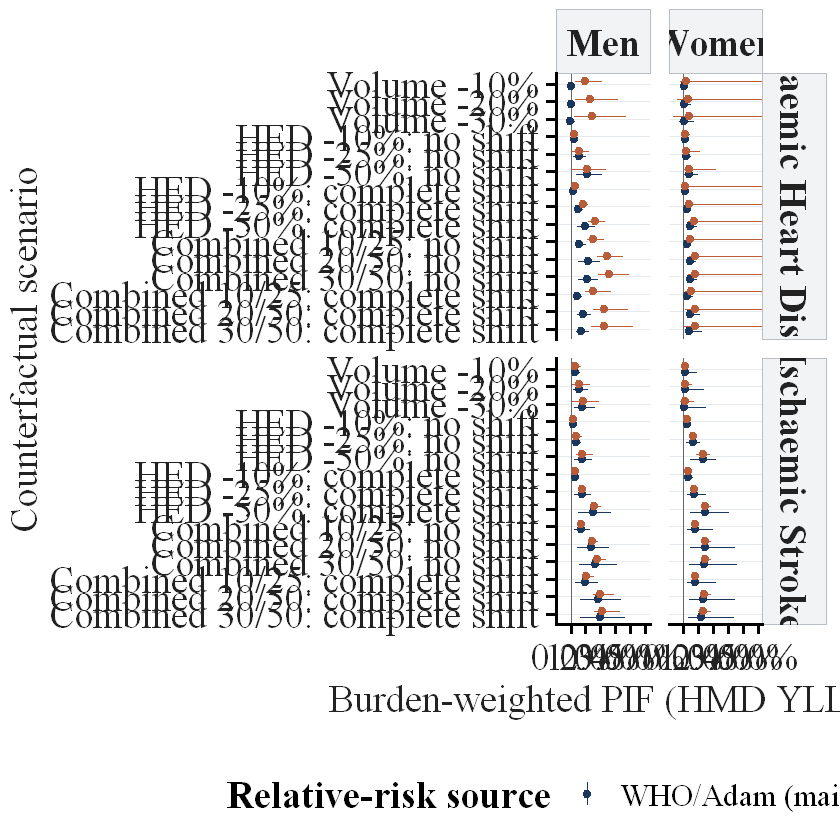

In [23]:
#| label: pif3-figure6-table5-rr-comparison

.t0 <- Sys.time()
pif3_rr_source_colors <- c("WHO/Adam (main)" = pif3_palette[["navy"]], "Table 5 PUC" = pif3_palette[["rust"]])
pif3_fig6_year <- base::max(pif3_cv_weighted$year)
# Baseline is dropped from the level set as well as from the data, otherwise coord_flip
# would render an empty "Baseline" row at the top of every panel.
pif3_fig6_levels <- base::unname(pif3_scenario_short[base::rev(base::setdiff(pif3_scenario_order, "baseline"))])
pif3_fig6_data <- pif3_cv_weighted |>
  dplyr::filter(.data$year == pif3_fig6_year, .data$scenario_id != "baseline") |>
  dplyr::mutate(scenario_short = base::factor(.data$scenario_short, levels = pif3_fig6_levels))
# The Table 5 IHD-female Monte Carlo upper tail is degenerate: a large share of its cells
# return upper limits near 1 while the point estimate stays near zero. Plotting the raw range
# would compress every other estimate into an unreadable strip at the left edge, so the panel
# is bounded by a high percentile of the upper limits and the overflow is counted, not hidden.
pif3_fig6_cap <- base::max(
  stats::quantile(pif3_fig6_data$pif_up, probs = 0.90, names = FALSE),
  base::max(pif3_fig6_data$pif)
) * 1.05
pif3_fig6_truncated <- pif3_fig6_data |>
  dplyr::filter(.data$pif_up > pif3_fig6_cap) |>
  dplyr::count(.data$disease, .data$sex_label, .data$rr_source, name = "intervals_beyond_panel") |>
  dplyr::filter(.data$intervals_beyond_panel > 0L)
pif3_fig6 <- ggplot2::ggplot(
  pif3_fig6_data,
  ggplot2::aes(x = .data$scenario_short, y = .data$pif, colour = .data$rr_source)
) +
  ggplot2::geom_hline(yintercept = 0, colour = "#666666", linewidth = 0.35) +
  ggplot2::geom_linerange(ggplot2::aes(ymin = .data$pif_low, ymax = .data$pif_up),
                          position = ggplot2::position_dodge(width = 0.6), linewidth = 0.45) +
  ggplot2::geom_point(position = ggplot2::position_dodge(width = 0.6), size = 1.5) +
  # The Table 5 IHD-female Monte Carlo upper tail is degenerate (see the diagnostic below), so
  # the panel is limited to a readable range. coord_flip(ylim = ...) clips the display only; no
  # row is dropped, and the number of intervals running past the edge is reported explicitly.
  ggplot2::coord_flip(ylim = c(base::min(pif3_fig6_data$pif_low), pif3_fig6_cap)) +
  ggplot2::facet_grid(rows = ggplot2::vars(.data$disease), cols = ggplot2::vars(.data$sex_label)) +
  ggplot2::scale_colour_manual(values = pif3_rr_source_colors) +
  ggplot2::scale_y_continuous(labels = scales::percent_format(accuracy = 0.1)) +
  ggplot2::labs(x = "Counterfactual scenario", y = "Burden-weighted PIF (HMD YLL weights)",
                colour = "Relative-risk source") +
  pif3_theme()

pif3_fig6_preview <- pif3_fig6 + pif3_theme(base_size = 23)

base::print(pif3_fig6_preview)

if (base::nrow(pif3_fig6_truncated)) {
  base::print(knitr::kable(pif3_fig6_truncated, format = "simple",
                           caption = base::sprintf("Uncertainty intervals extending beyond the plotted range (display cap %.1f%%)",
                                                   100 * pif3_fig6_cap)))
}
# Degenerate-tail diagnostic for the cell-level Table 5 grid, independent of the display cap.
pif3_table5_tail <- pif3_cv_table5_raw |>
  dplyr::filter(.data$scenario_id != "baseline", .data$applicable, base::is.finite(.data$pif_up)) |>
  dplyr::group_by(.data$disease, .data$sex) |>
  dplyr::summarise(cells = dplyr::n(),
                   median_pif = stats::median(.data$pif),
                   upper_above_50pct = base::sum(.data$pif_up > 0.5),
                   upper_above_90pct = base::sum(.data$pif_up > 0.9),
                   .groups = "drop")
base::print(knitr::kable(pif3_table5_tail, format = "simple", digits = 4,
                         caption = "Table 5 PUC Monte Carlo upper-tail behaviour by cause and sex")) 
pif3_save_plot(pif3_fig6, "figure6_table5_vs_who_ihd_is", width = 7.2, height = 6.4)
base::message(base::sprintf("pif3-figure6-table5-rr-comparison elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


In [24]:
#| label: pif3-table-s4-table5-comparison

.t0 <- Sys.time()
pif3_table_s4 <- pif3_cv_weighted |>
  dplyr::select(dplyr::all_of(c("year", "disease", "sex_label", "scenario_id", "scenario_short",
                                "rr_source", "observed_burden", "avoidable_burden",
                                "pif", "pif_low", "pif_up", "cells"))) |>
  tidyr::pivot_wider(
    id_cols = dplyr::all_of(c("year", "disease", "sex_label", "scenario_id", "scenario_short")),
    names_from = "rr_source",
    values_from = dplyr::all_of(c("avoidable_burden", "pif", "pif_low", "pif_up")),
    names_sep = "__"
  ) |>
  dplyr::arrange(.data$disease, .data$sex_label, .data$year,
                 base::match(.data$scenario_id, pif3_scenario_order))
pif3_table_s4_path <- base::file.path(pif3_table_dir, "tableS4_ihd_is_who_vs_table5_pif_2012_2024.csv")
if (isTRUE(pif3_export_figures)) {
  base::dir.create(pif3_table_dir, recursive = TRUE, showWarnings = FALSE)
  utils::write.csv(pif3_table_s4, pif3_table_s4_path, row.names = FALSE, fileEncoding = "UTF-8")
  pif3_message("[export] Saved: %s.", base::basename(pif3_table_s4_path))
}
pif3_show_table(
  pif3_table_s4 |>
    dplyr::filter(.data$year == pif3_fig6_year, .data$scenario_id != "baseline") |>
    dplyr::select(dplyr::all_of(c("disease", "sex_label", "scenario_short")),
                  dplyr::starts_with("avoidable_burden__"),
                  dplyr::starts_with("pif__")),
  digits = 4, caption = "Supplementary Table S4")
pif3_message("[table5] Supplementary Table S4 rows: %d.", base::nrow(pif3_table_s4))
base::message(base::sprintf("pif3-table-s4-table5-comparison elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[export] Saved: tableS4_ihd_is_who_vs_table5_pif_2012_2024.csv.



disease,sex_label,scenario_short,avoidable_burden__WHO/Adam (main),avoidable_burden__Table 5 PUC,pif__WHO/Adam (main),pif__Table 5 PUC
Ischaemic Heart Disease,Men,Volume -10%,10.8502,529.1339,0.0002,0.0094
Ischaemic Heart Disease,Men,Volume -20%,-2.5795,745.4587,0.0000,0.0132
Ischaemic Heart Disease,Men,Volume -30%,-38.0099,817.0861,-0.0007,0.0145
Ischaemic Heart Disease,Men,HED -10%: no shift,125.5467,124.8400,0.0022,0.0022
Ischaemic Heart Disease,Men,HED -25%: no shift,313.8667,312.0999,0.0056,0.0055
Ischaemic Heart Disease,Men,HED -50%: no shift,627.7334,624.1998,0.0111,0.0111
Ischaemic Heart Disease,Men,HED -10%: complete shift,105.9870,183.9730,0.0019,0.0033
Ischaemic Heart Disease,Men,HED -25%: complete shift,264.9675,459.9325,0.0047,0.0082
Ischaemic Heart Disease,Men,HED -50%: complete shift,529.9350,919.8650,0.0094,0.0163
Ischaemic Heart Disease,Men,Combined 10/25: no shift,329.5775,843.4138,0.0058,0.0150


[table5] Supplementary Table S4 rows: 448.



pif3-table-s4-table5-comparison elapsed minutes: 0.00



### Why do the women’s PIFs look extreme?

- This is not a general pattern in women: it is concentrated in the **PUC/Table 5 estimate for female ischaemic heart disease**.

- The PIF point estimates are small. The problem is the **very large upper uncertainty limits**.

- The plot is capped at ~5%; several PUC female-IHD intervals actually extend to **10–100%**, so they are visually truncated at the right edge.

- The PUC RR function is highly sensitive at high consumption levels (Roerecke & Rehm, 2012):

  $$
  \log(RR) = -0.052526x + 0.014704x\log(x)
  $$

- Simulated uncertainty in this nonlinear RR curve can generate extremely large RR values, pushing simulated PIFs towards 100%.

- The curve is J-shaped, so volume- and HED-based scenarios are not expected to be perfectly monotonic.

- `Fact = 1/20` is reported for female IHD, but its intended use is not defined in the available source. It should be verified before interpreting these uncertainty intervals substantively.

| Exposure | WHO2024 IHD male | Table 5 IHD male |
|----------|-------------------|------------------|
| 30 g/d   | 0.779             | 0.797            |
| 60 g/d   | 1.000             | 0.867            |
| 80 g/d   | 1.000 ← flat plateau | 1.103         |
| 99 g/d   | 1.000             | 1.665            |
| 150 g/d  | 1.822             | 16.58            |

[rr-curve] Sourced rr_registry_adam.R for load_adam_rr_registry().



[export] Saved: figure8_ihd_is_rr_curve_mechanism.tiff and figure8_ihd_is_rr_curve_mechanism.pdf.



pif3-figure8-rr-curve-mechanism elapsed minutes: 0.02



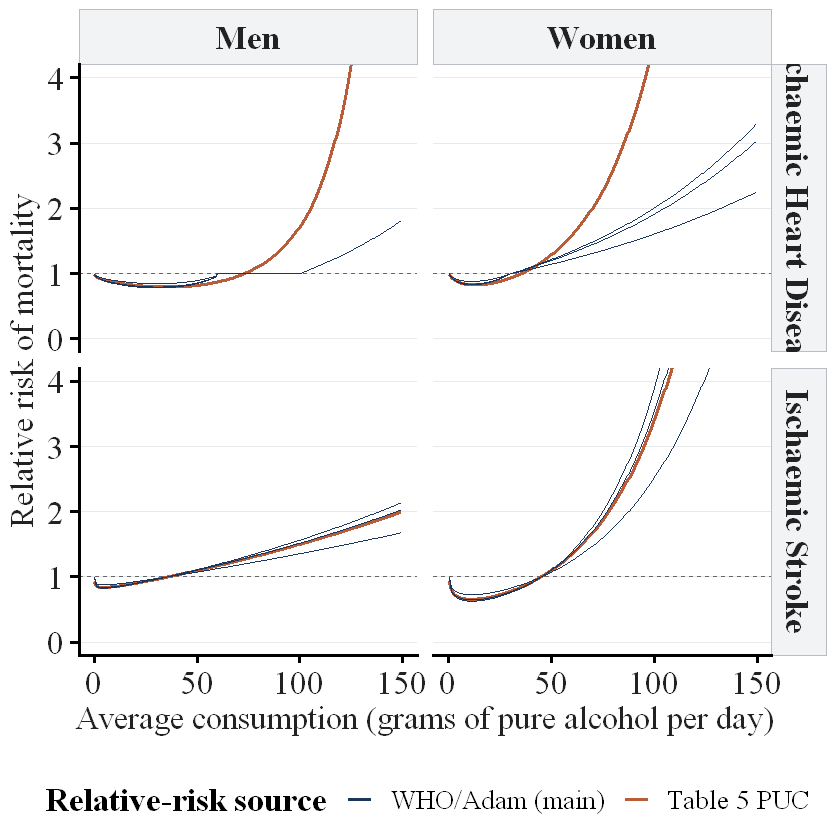

In [25]:
#| label: pif3-figure8-rr-curve-mechanism
#| fig-width: 7.2 
#| fig-height: 5.2 
#| fig-dpi: 300

.t0 <- Sys.time()
pif3_rr_registry_loader <- base::file.path(pif3_dirs$control, "rr_registry_adam.R")
if (!base::exists("load_adam_rr_registry")) {
  if (!base::file.exists(pif3_rr_registry_loader)) base::stop("rr_registry_adam.R not found: ", pif3_rr_registry_loader)
  base::source(pif3_rr_registry_loader)
  pif3_message("[rr-curve] Sourced %s for load_adam_rr_registry().", base::basename(pif3_rr_registry_loader))
}
pif3_rr_registry_ihd <- load_adam_rr_registry(scope = "ihd", control_dir = pif3_dirs$control, verbose = FALSE)
pif3_rr_registry_is  <- load_adam_rr_registry(scope = "is",  control_dir = pif3_dirs$control, verbose = FALSE)
# Table 5 PUC closed forms and coefficients, replicated from aaf_table5_ihd_is_experiment.R.
pif3_table5_curves <- list(
  "Ischaemic Heart Disease::male"   = function(x) exp(-0.046271 * sqrt(x) + 0.000001 * x^3),
  "Ischaemic Heart Disease::female" = function(x) exp(-0.052526 * x + 0.014704 * x * base::log(x)),
  "Ischaemic Stroke::male"          = function(x) exp(-0.141950 * sqrt(x) + 0.039613 * sqrt(x) * base::log(x)),
  "Ischaemic Stroke::female"        = function(x) exp(-0.249674 * sqrt(x) + 0.037207 * x)
)
pif3_rr_grid <- base::seq(0.1, 150, by = 0.5)
pif3_rr_who_curve <- function(registry, disease_label, sex_key) {
  records <- registry[base::grepl(base::paste0("^", sex_key, "::"), base::names(registry))]
  dplyr::bind_rows(base::lapply(base::seq_along(records), function(i) {
    rec <- records[[i]]
    tibble::tibble(disease = disease_label, sex = sex_key, rr_source = "WHO/Adam (main)",
                   series = base::paste0("WHO band ", rec$adam_age_band), g_per_day = pif3_rr_grid,
                   rr = vapply(pif3_rr_grid, function(v) rec$RRCurrent(v, rec$betaCurrent), numeric(1)))
  }))
}
pif3_rr_table5_curve <- function(disease_label, sex_key) {
  fun <- pif3_table5_curves[[base::paste0(disease_label, "::", sex_key)]]
  tibble::tibble(disease = disease_label, sex = sex_key, rr_source = "Table 5 PUC",
                 series = "Table 5 PUC", g_per_day = pif3_rr_grid, rr = fun(pif3_rr_grid))
}
pif3_rr_curve_data <- dplyr::bind_rows(
  pif3_rr_who_curve(pif3_rr_registry_ihd, "Ischaemic Heart Disease", "male"),
  pif3_rr_who_curve(pif3_rr_registry_ihd, "Ischaemic Heart Disease", "female"),
  pif3_rr_who_curve(pif3_rr_registry_is,  "Ischaemic Stroke",        "male"),
  pif3_rr_who_curve(pif3_rr_registry_is,  "Ischaemic Stroke",        "female"),
  pif3_rr_table5_curve("Ischaemic Heart Disease", "male"),
  pif3_rr_table5_curve("Ischaemic Heart Disease", "female"),
  pif3_rr_table5_curve("Ischaemic Stroke",        "male"),
  pif3_rr_table5_curve("Ischaemic Stroke",        "female")
) |>
  dplyr::mutate(sex_label = base::unname(pif3_sex_labels[.data$sex]),
                rr_source = base::factor(.data$rr_source, levels = pif3_rr_source_levels))
pif3_fig8 <- ggplot2::ggplot(pif3_rr_curve_data,
                             ggplot2::aes(x = .data$g_per_day, y = .data$rr,
                                          colour = .data$rr_source, group = .data$series)) +
  ggplot2::geom_hline(yintercept = 1, colour = "#666666", linewidth = 0.35, linetype = "dashed") +
  ggplot2::geom_line(ggplot2::aes(linewidth = .data$rr_source)) +
  ggplot2::facet_grid(rows = ggplot2::vars(.data$disease), cols = ggplot2::vars(.data$sex_label),
                      scales = "free_y") +
  ggplot2::scale_colour_manual(values = pif3_rr_source_colors) +
  ggplot2::scale_linewidth_manual(values = c("WHO/Adam (main)" = 0.5, "Table 5 PUC" = 0.9), guide = "none") +
  ggplot2::coord_cartesian(ylim = c(0, 4)) +
  ggplot2::labs(x = "Average consumption (grams of pure alcohol per day)",
                y = "Relative risk of mortality", colour = "Relative-risk source") +
  pif3_theme()
base::print(pif3_fig8+ pif3_theme(base_size=20))
pif3_save_plot(pif3_fig8, "figure8_ihd_is_rr_curve_mechanism", width = 7.2, height = 5.2)
base::message(base::sprintf("pif3-figure8-rr-curve-mechanism elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


[latest-file] Pattern: ^pif2_pif_results_table5_full_([0-9]{8})\.rds$



[latest-file] Candidate count: 4



[latest-file] Selected by embedded date: pif2_pif_results_table5_full_20260721.rds



[read-rds] Reading: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/pif2_pif_results_table5_full_20260721.rds



[export] Saved: figure_burden_who_vs_table5_ihd.tiff and figure_burden_who_vs_table5_ihd.pdf.



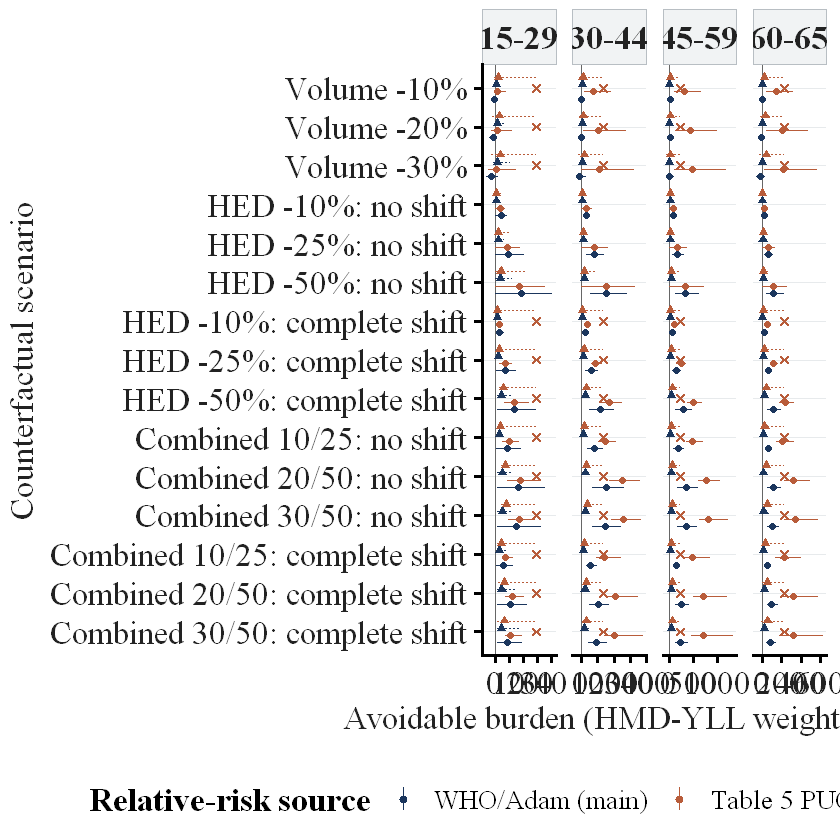

[export] Saved: figure_burden_who_vs_table5_is.tiff and figure_burden_who_vs_table5_is.pdf.



pif3-figure-burden-who-vs-table5 elapsed minutes: 0.08



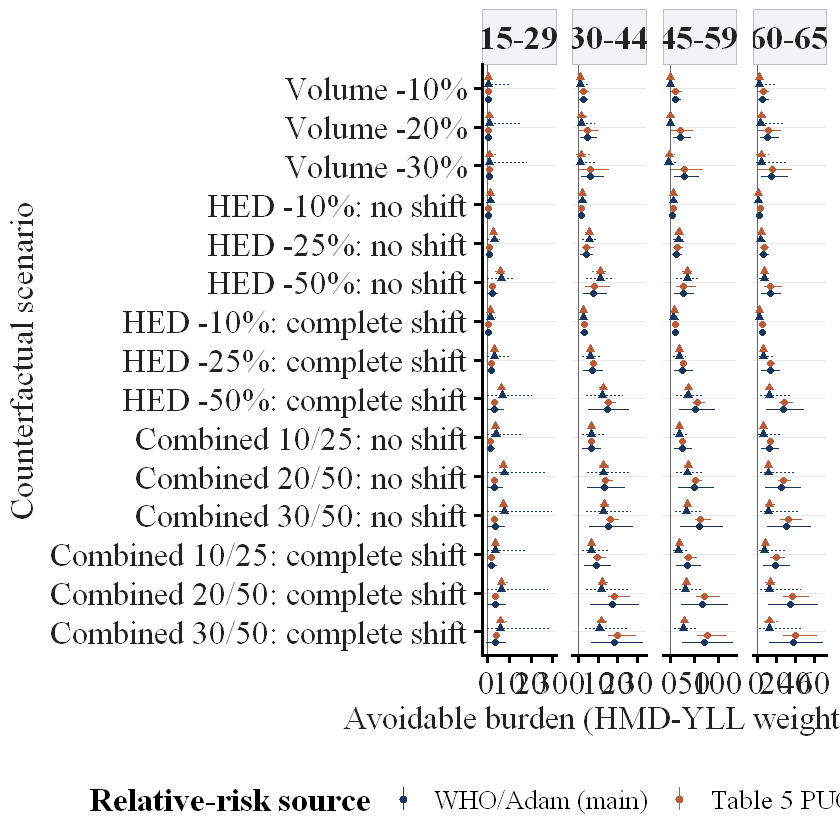

In [26]:
#| label: pif3-figure-burden-who-vs-table5
#| fig-width: 11
#| fig-height: 6.8
#| fig-dpi: 300
.t0 <- Sys.time()
# One chunk, ONE figure per cause (IHD, then IS): avoidable HMD-YLL burden, WHO/Adam vs Table 5
# PUC relative risks, by age group (panels), year 2024, with cell-level lower and upper limits.
# Colour = relative-risk source; SEX = line type and point shape. Loads the latest Table 5 PUC
# grid and reuses the notebook's own pif3_burden for the WHO/Adam source.
pif3_cv_levels <- c("WHO/Adam (main)", "Table 5 PUC")
pif3_cv_diseases <- c("Ischaemic Heart Disease", "Ischaemic Stroke")
pif3_t5_burden <- pif3_read_rds(pif3_latest_dated_file(pif3_dirs$control, "pif2_pif_results_table5_full")) |>
  tibble::as_tibble() |>
  dplyr::select(-dplyr::any_of(c("hed_exit_mix", "hed_exit_shift", "exit_rule", "scale",
                                 "rr_source", "policy_vol_lever_pct", "implied_vol_change_pct"))) |>
  pif3_enrich_pif() |>
  dplyr::mutate(rr_source = "Table 5 PUC")
pif3_burden_compare <- dplyr::bind_rows(
  pif3_burden |>
    dplyr::filter(.data$disease %in% pif3_cv_diseases) |>
    dplyr::mutate(rr_source = "WHO/Adam (main)"),
  pif3_t5_burden
) |>
  dplyr::filter(.data$year == 2024, .data$applicable, base::is.finite(.data$avoidable_yll_hmd),
                .data$scenario_id != "baseline") |>
  dplyr::mutate(
    rr_source = base::factor(.data$rr_source, levels = pif3_cv_levels),
    sex_label = base::factor(.data$sex_label, levels = c("Men", "Women")),
    age_label = base::factor(.data$age_label, levels = base::unname(pif3_age_labels)),
    scenario_short = base::factor(base::unname(pif3_scenario_short[.data$scenario_id]),
                                  levels = base::unname(pif3_scenario_short[base::rev(base::setdiff(pif3_scenario_order, "baseline"))])),
    series = base::interaction(.data$rr_source, .data$sex_label, drop = TRUE)
  ) |>
  # Per-series (disease x age x sex) display cap: Table 5 IHD-female upper limit is degenerate
  # (missing b1/b2 covariance). Cap each sex against its OWN effect size so a female clipped line
  # does not span the whole panel; never clip the WHO/Adam source.
  dplyr::group_by(.data$disease, .data$age_label, .data$sex_label) |>
  dplyr::mutate(
    cap = base::max(4 * base::max(base::abs(.data$avoidable_yll_hmd)),
                    1.05 * base::max(.data$avoidable_yll_hmd_up[.data$rr_source == "WHO/Adam (main)"])),
    up_display = base::pmin(.data$avoidable_yll_hmd_up, .data$cap),
    clipped = .data$avoidable_yll_hmd_up > .data$cap
  ) |>
  dplyr::ungroup()
pif3_dodge <- ggplot2::position_dodge(width = 0.75)
pif3_burden_disease_fig <- function(cause) {
  dat <- pif3_burden_compare |> dplyr::filter(.data$disease == cause)
  ggplot2::ggplot(dat, ggplot2::aes(x = .data$scenario_short, y = .data$avoidable_yll_hmd,
                                    colour = .data$rr_source, linetype = .data$sex_label,
                                    shape = .data$sex_label, group = .data$series)) +
    ggplot2::geom_hline(yintercept = 0, colour = "#666666", linewidth = 0.3) +
    ggplot2::geom_linerange(ggplot2::aes(ymin = .data$avoidable_yll_hmd_low, ymax = .data$up_display),
                            position = pif3_dodge, linewidth = 0.45) +
    ggplot2::geom_point(position = pif3_dodge, size = 1.5) +
    ggplot2::geom_point(data = dplyr::filter(dat, .data$clipped), ggplot2::aes(y = .data$up_display),
                        position = pif3_dodge, shape = 4, size = 1.6, show.legend = FALSE) +
    ggplot2::coord_flip() +
    ggplot2::facet_wrap(ggplot2::vars(.data$age_label), nrow = 1, scales = "free_x") +
    ggplot2::scale_colour_manual(values = c("WHO/Adam (main)" = pif3_palette[["navy"]], "Table 5 PUC" = pif3_palette[["rust"]])) +
    ggplot2::scale_linetype_manual(values = c("Men" = "solid", "Women" = "22")) +
    ggplot2::scale_shape_manual(values = c("Men" = 16, "Women" = 17)) +
    ggplot2::labs(x = "Counterfactual scenario", y = "Avoidable burden (HMD-YLL weighted), 2024",
                  colour = "Relative-risk source", linetype = "Sex", shape = "Sex") +
    pif3_theme(base_size = 8)
}
pif3_fig_burden_ihd <- pif3_burden_disease_fig("Ischaemic Heart Disease")
base::print(pif3_fig_burden_ihd+ pif3_theme(base_size=20))
pif3_save_plot(pif3_fig_burden_ihd, "figure_burden_who_vs_table5_ihd", width = 11, height = 6.8)
pif3_fig_burden_is <- pif3_burden_disease_fig("Ischaemic Stroke")
base::print(pif3_fig_burden_is+ pif3_theme(base_size=20))
pif3_save_plot(pif3_fig_burden_is, "figure_burden_who_vs_table5_is", width = 11, height = 6.8)
base::message(base::sprintf("pif3-figure-burden-who-vs-table5 elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


## References

Kilian C, Buckley C, Lemp JM, et al. Targeting alcohol use in high risk population groups: a US microsimulation study of beverage-specific pricing policies. *The Lancet Public Health*. 2025. https://doi.org/10.1016/S2468-2667(25)00165-3

Shield K, Franklin A, Wettlaufer A, et al. National, regional, and global statistics on alcohol consumption and associated burden of disease 2000-20: a modelling study and comparative risk assessment. *The Lancet Public Health*. 2025;10:e751.

Roerecke M, Rehm J. The cardioprotective association of average alcohol consumption and ischaemic heart disease: a systematic review and meta-analysis. Addiction. 2012 Jul;107(7):1246-60. doi: 10.1111/j.1360-0443.2012.03780.x. Epub 2012 Mar 21. PMID: 22229788; PMCID: PMC3348338.

# Session info


In [27]:
#| label: pif3-session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true
.t0 <- Sys.time()
base::message(base::paste0("R library: ", base::Sys.getenv("R_LIBS_USER")))
base::message(base::paste0("Date: ", withr::with_locale(new = c("LC_TIME" = "C"), code = base::Sys.time())))
base::message(base::paste0("Editor context: ", base::getwd()))
pif3_quarto_executable <- base::Sys.which("quarto")
if (base::nzchar(pif3_quarto_executable)) {
  pif3_quarto_version <- base::tryCatch(base::system2(pif3_quarto_executable, "--version", stdout = TRUE, stderr = FALSE)[[1L]], error = function(e) base::paste0("unavailable: ", base::conditionMessage(e)))
  base::message(base::paste0("Quarto version: ", pif3_quarto_version))
} else {
  base::message("Quarto command-line executable was not found on PATH.")
}
pif3_session_info <- utils::sessionInfo()
base::print(pif3_session_info)
pif3_package_descriptions <- c(pif3_session_info$otherPkgs, pif3_session_info$loadedOnly)
tabla_pkg <- tibble::tibble(Package = base::names(pif3_package_descriptions), Version = base::vapply(pif3_package_descriptions, function(package) package$Version, character(1)), Source = base::vapply(pif3_package_descriptions, function(package) if (base::is.null(package$Repository)) "local" else package$Repository, character(1)))
tabla_pkg <- tibble::rowid_to_column(tabla_pkg, var = "Row number")
pif3_session_table <- knitr::kable(tabla_pkg, format = "html", table.attr = "style='border-collapse:collapse;width:max-content;min-width:100%;white-space:nowrap;font-family:Arial,sans-serif;font-size:70%;'")
htmltools::browsable(htmltools::tags$div(style = "max-height:420px;overflow:auto;border:1px solid #ddd;width:100%;", htmltools::tags$p(style = "font-family:Arial,sans-serif;font-size:84%;font-style:italic;margin:6px 4px;", "R packages"), htmltools::HTML(pif3_session_table)))
base::message(base::sprintf("pif3-session-info elapsed minutes: %.2f", pif3_elapsed_min(.t0)))


R library: C:\Users\nDP\AppData\Local/R/win-library/4.4



Date: 2026-07-21 09:44:30.112735



Editor context: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control



Quarto command-line executable was not found on PATH.



R version 4.4.1 (2024-06-14 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default


locale:
[1] LC_COLLATE=Spanish_Chile.utf8  LC_CTYPE=Spanish_Chile.utf8   
[3] LC_MONETARY=Spanish_Chile.utf8 LC_NUMERIC=C                  
[5] LC_TIME=Spanish_Chile.utf8    

time zone: America/Santiago
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

loaded via a namespace (and not attached):
 [1] gtable_0.3.6       jsonlite_2.0.0     dplyr_1.2.0        compiler_4.4.1    
 [5] crayon_1.5.3       tidyselect_1.2.1   IRdisplay_1.1      tidyr_1.3.2       
 [9] systemfonts_1.3.2  scales_1.4.0       textshaping_1.0.5  readxl_1.4.5      
[13] uuid_1.2-2         fastmap_1.2.0      IRkernel_1.3.2     ggplot2_4.0.2     
[17] R6_2.6.1           labeling_0.4.3     generics_0.1.4     knitr_1.51        
[21] forcats_1.0.1      tibble_3.3.1       pillar_1.11.1      RColorBrewer_1.1-3
[25]

Row number,Package,Version,Source
1,gtable,0.3.6,CRAN
2,jsonlite,2.0.0,CRAN
3,dplyr,1.2.0,CRAN
4,compiler,4.4.1,local
5,crayon,1.5.3,CRAN
6,tidyselect,1.2.1,CRAN
7,IRdisplay,1.1,CRAN
8,tidyr,1.3.2,CRAN
9,systemfonts,1.3.2,CRAN
10,scales,1.4.0,CRAN


pif3-session-info elapsed minutes: 0.00

